# Trabalho 2: Aprendizado de Máquina

### Dupla

Andreina Maria Mendes da Silva - 485306  
Augusto César Araújo de Oliveira - 508991

### Divisão de tarefas


 #### Andreina


- Análise dos Dados
- Pré-Processamento dos Dados
- Kmeans
- Avaliação dos resultados

 #### Augusto


- Análise dos Dados
- Clusterização Hierárquica
- DBScan
- Avaliação dos resultados
- Apresentação dos resultados

## Descrição do Trabalho

- Seleção do conjunto de dados
    - O conjunto de dados deve ter no mínimo 6 características (features) e 1000 amostras.
    - O conjunto de dados usado para clusterização NÃO pode ter target.
    - Não usar um conjunto de dados já usado no Trabalho Prático 1.
- Importação dos dados
- Análise dos dados
- Pré-processamento dos dados
    - Limpar o conjunto de dados, tratando valores faltantes e outliers.
    - Normalizar os dados, se necessário.
- Uso de técnicas de clusterização
    - Usar k-Means, DBScan e Clusterização Hierárquica
        - Avaliar o melhor valor de k no k-means usando o método do cotovelo e a análise de silhueta.
        - Avaliar o melhor valor de k na clusterização hierárquica usando Análise Hierárquica de Cluster (HCA).
- Avaliação dos resultados
    - avaliar os resultados usando métricas como:
        - Silhouette Score
        - Davies-Bouldin Score
        - Normalized Mutual Info Score
        - Calinski and Harabasz Score
- Apresentação dos resultados
    - Visualizar os resultados da clusterização em 2 dimensões usando as técnicas PCA e t-SNE.

# Importação das bibliotecas

In [ ]:
!pip install yellowbrick

In [16]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from datetime import datetime
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D

import yellowbrick.cluster as yb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Importação dos Dados

In [2]:
data = pd.read_csv('Live_20210128.csv')
data

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7045,7046,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0,NaN,NaN,NaN,NaN
7046,7047,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0,NaN,NaN,NaN,NaN
7047,7048,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0,NaN,NaN,NaN,NaN
7048,7049,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0,NaN,NaN,NaN,NaN


# Análise de dados

- Dataset: [Facebook Live Sellers in Thailand](https://archive.ics.uci.edu/dataset/488/facebook+live+sellers+in+thailand)

O conjunto de dados contém páginas do Facebook de 10 vendedores de varejo de moda e cosméticos tailandeses. Os dados estão organizados em postagens de natureza diferente (vídeo, fotos, status e links). As métricas de engajamento consistem em comentários, compartilhamentos e reações.

- Objetivo: agrupar pelo impacto da publicação, isto é, pelas métricas de engajamento como comentários, compartilhamentos e reações.

### Dicionário dos Dados

In [ ]:
data_dict = pd.DataFrame({'Características': ['status_id',
                                          'status_type',
                                          'status_published',
                                          'num_reactions',
                                          'num_comments',
                                          'num_shares',
                                          'num_likes',
                                          'num_loves',
                                          'num_wows',
                                          'num_hahas',
                                          'num_sads',
                                          'num_angrys'],
                          'Descrições': ['Informa o ID da postagem',
                                        'Informa o tipo da postagem (vídeo, link, foto e status)',
                                        'Informa a data de publicação do post',
                                        'Informa o número de reações',
                                        'Informa o número de comentários',
                                        'Informa o número de compartilhamentos',
                                        'Informa o número de curtidas',
                                        'Informa o número de corações',
                                        'Informa o número de emojis surpresos (wow)',
                                        'Informa o número de emojis rindo',
                                        'Informa o número de emojis tristes',
                                        'Informa o número de emojis com raiva']})

data_dict

,Características,Descrições
0,status_id,Informa o ID da postagem
1,status_type,"Informa o tipo da postagem (vídeo, link, foto ..."
2,status_published,Informa a data de publicação do post
3,num_reactions,Informa o número de reações
4,num_comments,Informa o número de comentários
5,num_shares,Informa o número de compartilhamentos
6,num_likes,Informa o número de curtidas
7,num_loves,Informa o número de corações
8,num_wows,Informa o número de emojis surpresos (wow)
9,num_hahas,Informa o número de emojis rindo


### Detalhes do conjunto de dados

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   int64  
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(10), object(2)
memory

### Descrição dos dados

In [ ]:
data.describe()

,status_id,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,0.0,0.0,0.0,0.0
mean,3525.500000,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191,NaN,NaN,NaN,NaN
std,2035.304031,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812,NaN,NaN,NaN,NaN
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,1763.250000,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,3525.500000,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,5287.750000,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
max,7050.000000,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000,NaN,NaN,NaN,NaN


### Verificação de dados faltantes

In [ ]:
data.isna().sum().sort_values()

,0
status_id,0
status_type,0
status_published,0
num_reactions,0
num_comments,0
num_shares,0
num_likes,0
num_loves,0
num_wows,0
num_hahas,0


### Matriz de Correlação

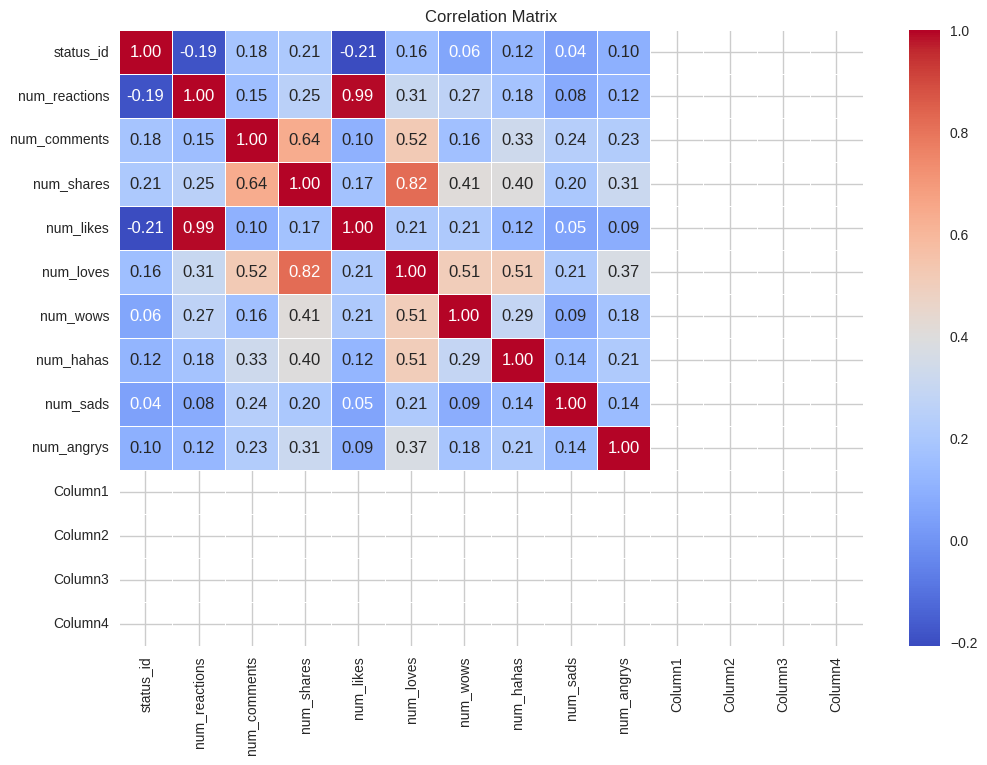

In [ ]:
numeric_df = data.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

## Histogramas

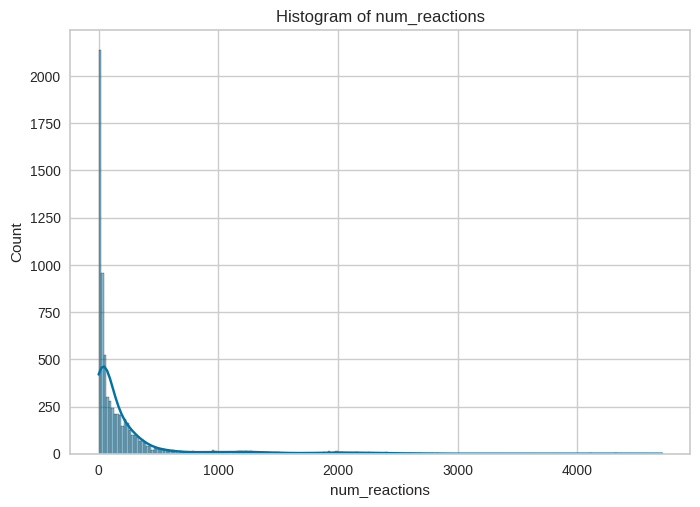

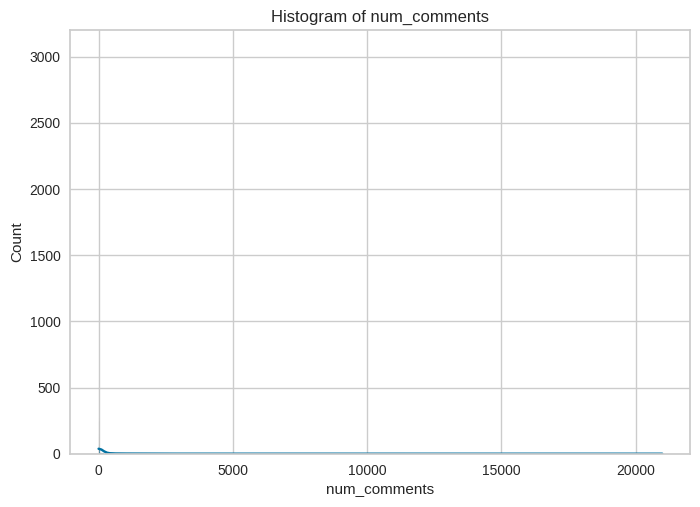

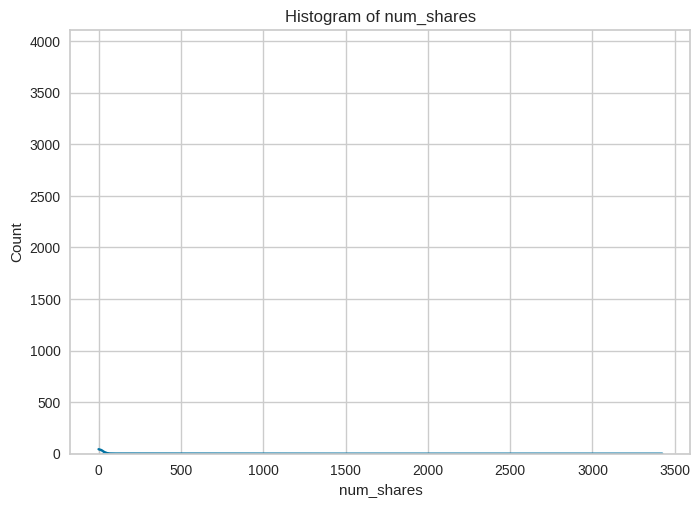

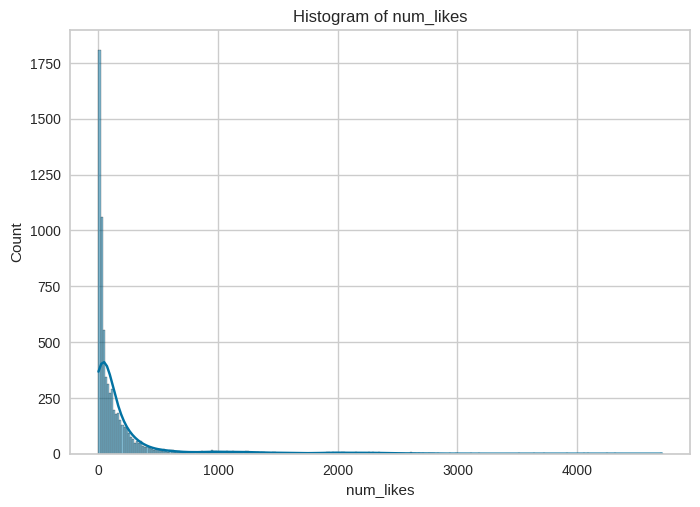

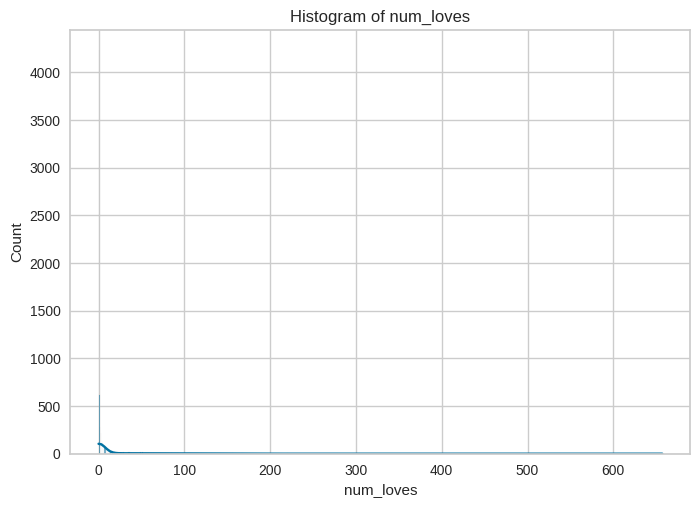

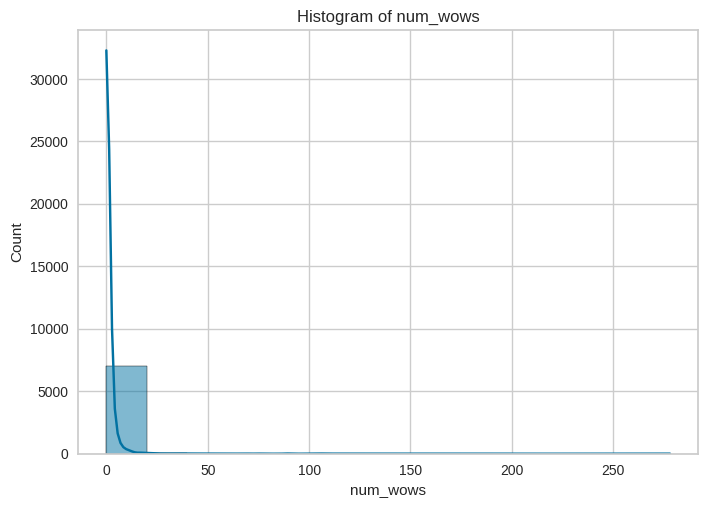

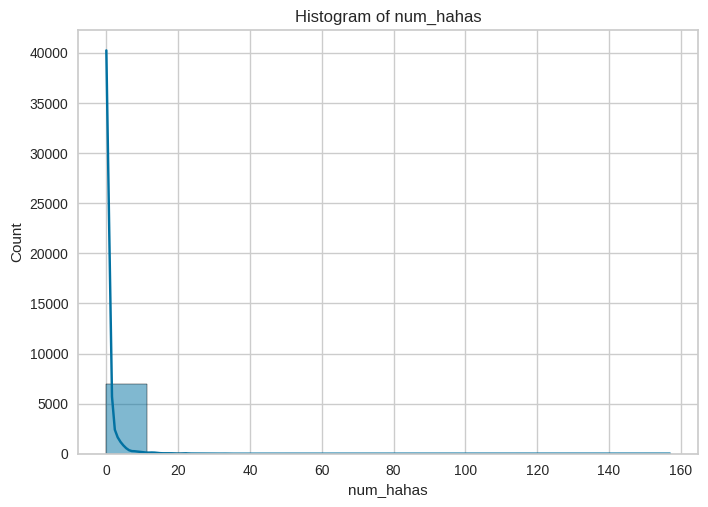

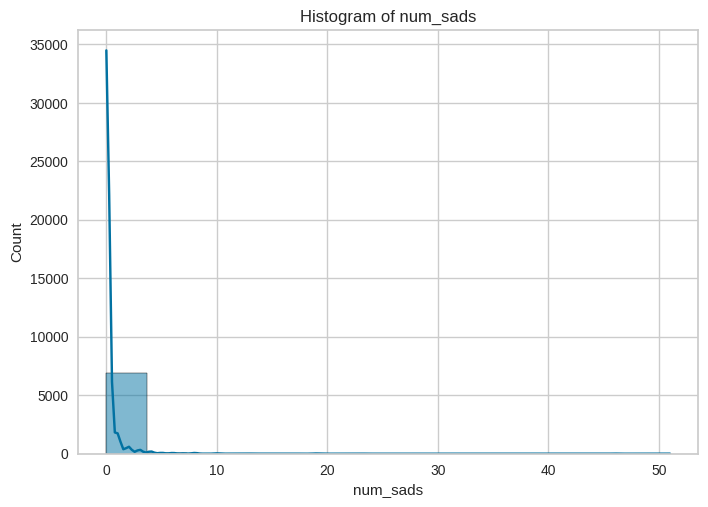

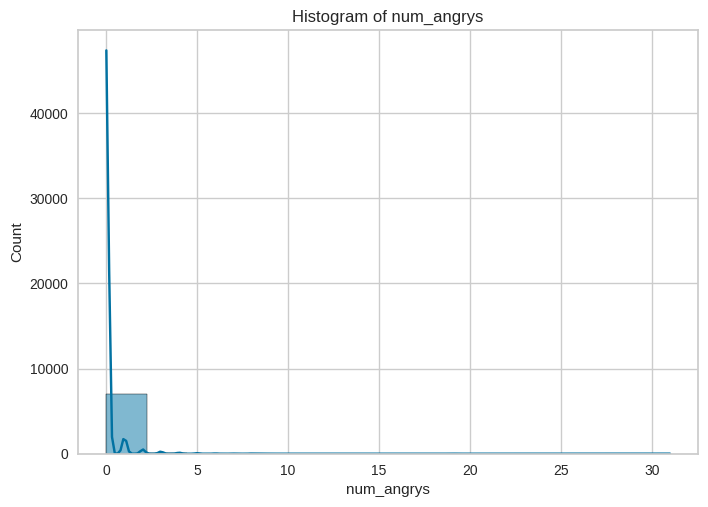

In [47]:
for column in data.columns:
    plt.figure()
    sns.histplot(data[column], kde=True)
    plt.title(f'Histogram of {column}')
    plt.show()

# Pré-processamento dos dados

### Seleção de características

In [3]:
data = data.iloc[:, :-4]
data = data.drop(['status_type', 'status_published', 'status_id'], axis=1)
data

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,529,512,262,432,92,3,1,1,0
1,150,0,0,150,0,0,0,0,0
2,227,236,57,204,21,1,1,0,0
3,111,0,0,111,0,0,0,0,0
4,213,0,0,204,9,0,0,0,0
...,...,...,...,...,...,...,...,...,...
7045,89,0,0,89,0,0,0,0,0
7046,16,0,0,14,1,0,1,0,0
7047,2,0,0,1,1,0,0,0,0
7048,351,12,22,349,2,0,0,0,0


### Normalização de dados numéricos

In [4]:
normalizacao = StandardScaler()
normalized_data = normalizacao.fit_transform(data)
data_normalized = pd.DataFrame(normalized_data, columns = data.columns)
data_normalized

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,0.646104,0.323350,1.686879,0.482727,1.983266,0.196196,0.076713,0.473570,-0.155748
1,-0.173192,-0.252206,-0.304144,-0.144720,-0.318454,-0.147879,-0.176010,-0.152587,-0.155748
2,-0.006738,0.013089,0.129017,-0.024571,0.206938,-0.033187,0.076713,-0.152587,-0.155748
3,-0.257499,-0.252206,-0.304144,-0.231495,-0.318454,-0.147879,-0.176010,-0.152587,-0.155748
4,-0.037003,-0.252206,-0.304144,-0.024571,-0.093286,-0.147879,-0.176010,-0.152587,-0.155748
...,...,...,...,...,...,...,...,...,...
7045,-0.305057,-0.252206,-0.304144,-0.280445,-0.318454,-0.147879,-0.176010,-0.152587,-0.155748
7046,-0.462863,-0.252206,-0.304144,-0.447319,-0.293436,-0.147879,0.076713,-0.152587,-0.155748
7047,-0.493128,-0.252206,-0.304144,-0.476244,-0.293436,-0.147879,-0.176010,-0.152587,-0.155748
7048,0.261316,-0.238717,-0.136959,0.298053,-0.268417,-0.147879,-0.176010,-0.152587,-0.155748


# Técnicas de Clusterização

- Definição de um dataframe final para clusterização

In [5]:
df_final = data_normalized.copy()
df_final

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,0.646104,0.323350,1.686879,0.482727,1.983266,0.196196,0.076713,0.473570,-0.155748
1,-0.173192,-0.252206,-0.304144,-0.144720,-0.318454,-0.147879,-0.176010,-0.152587,-0.155748
2,-0.006738,0.013089,0.129017,-0.024571,0.206938,-0.033187,0.076713,-0.152587,-0.155748
3,-0.257499,-0.252206,-0.304144,-0.231495,-0.318454,-0.147879,-0.176010,-0.152587,-0.155748
4,-0.037003,-0.252206,-0.304144,-0.024571,-0.093286,-0.147879,-0.176010,-0.152587,-0.155748
...,...,...,...,...,...,...,...,...,...
7045,-0.305057,-0.252206,-0.304144,-0.280445,-0.318454,-0.147879,-0.176010,-0.152587,-0.155748
7046,-0.462863,-0.252206,-0.304144,-0.447319,-0.293436,-0.147879,0.076713,-0.152587,-0.155748
7047,-0.493128,-0.252206,-0.304144,-0.476244,-0.293436,-0.147879,-0.176010,-0.152587,-0.155748
7048,0.261316,-0.238717,-0.136959,0.298053,-0.268417,-0.147879,-0.176010,-0.152587,-0.155748


- Função para visualizar os gráficos de Silhueta

In [6]:
def silhouetteFunction(df, clusterMet):
    visualizer = SilhouetteVisualizer(clusterMet, colors = 'yellowbrick')
    visualizer.fit(df)
    visualizer.show();

## KMEANS

### Avaliação do melhor K

In [ ]:
values = []
scores_values = []
possibles = range(2,15)

for i in possibles:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    y_kmeans = kmeans.fit_predict(df_final)
    values.append(kmeans.inertia_)
    score = silhouette_score(df_final, y_kmeans, random_state=42)
    scores_values.append(score)

#### Método do Cotovelo

- Gráfico

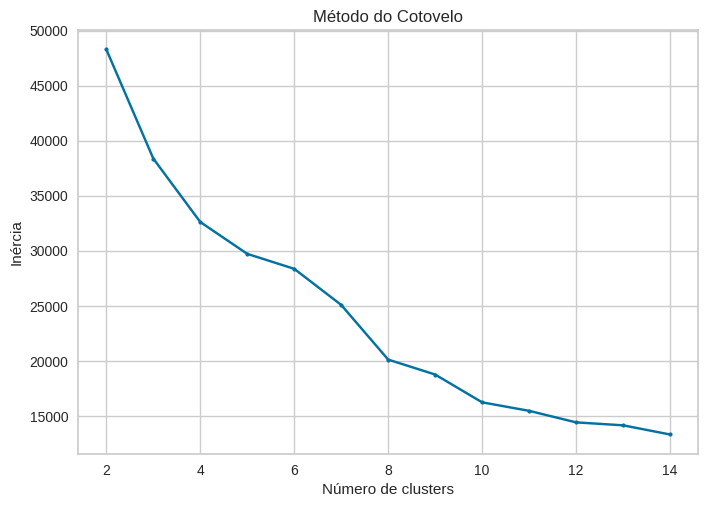

In [ ]:
plt.plot(possibles, values, 'bo-', markersize=3)
plt.title('Método do Cotovelo')
plt.xlabel('Número de clusters')
plt.ylabel('Inércia')
plt.show()

#### Silhouette Score

- Gráfico de comparação dos Silhouette Scores

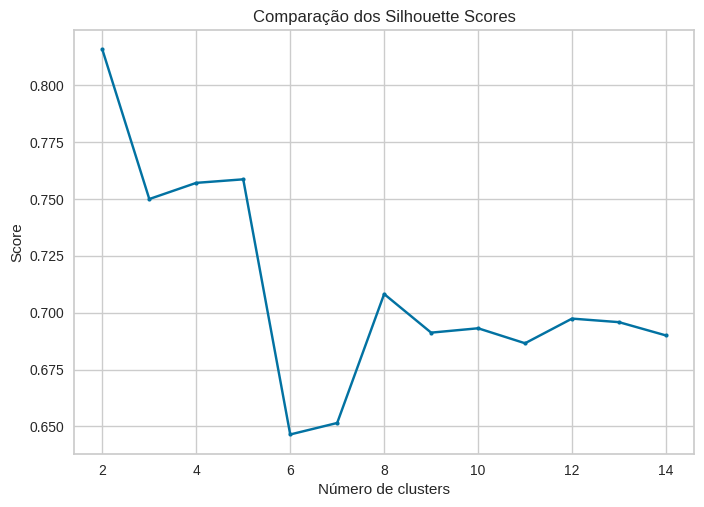

In [ ]:
plt.plot(possibles, scores_values, 'bo-', markersize=3)
plt.title('Comparação dos Silhouette Scores')
plt.xlabel('Número de clusters')
plt.ylabel('Score')
plt.show()

#### Silhouette Visualizer

- Gráfico

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


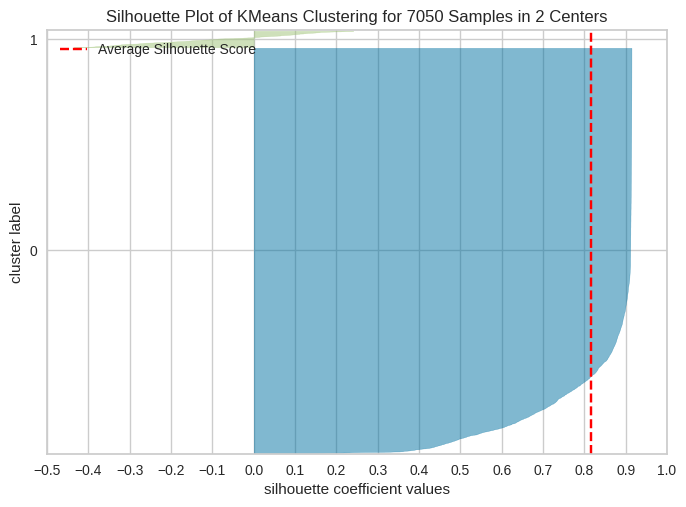

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


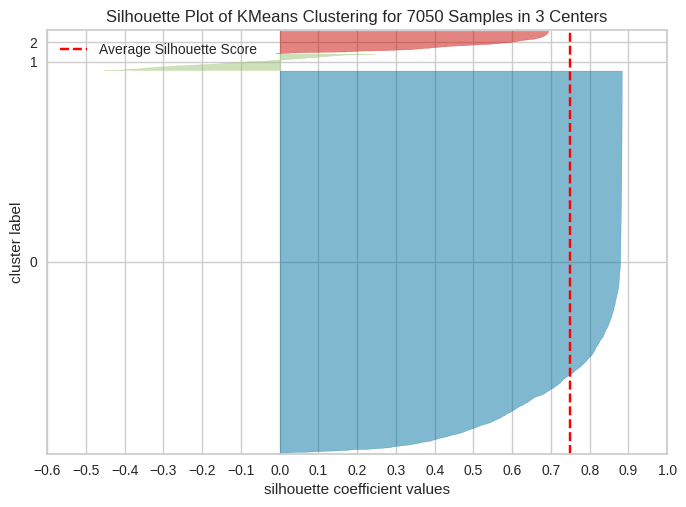

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


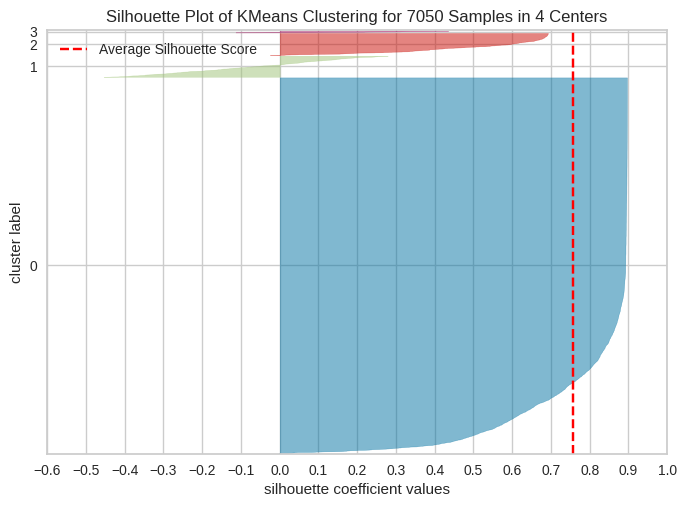

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


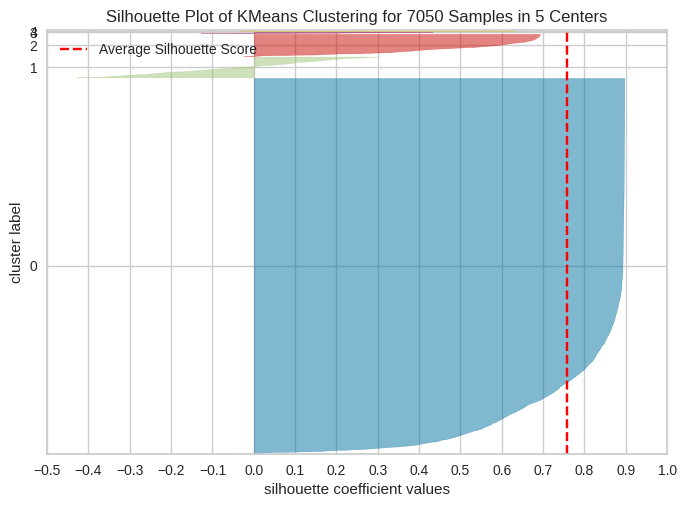

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


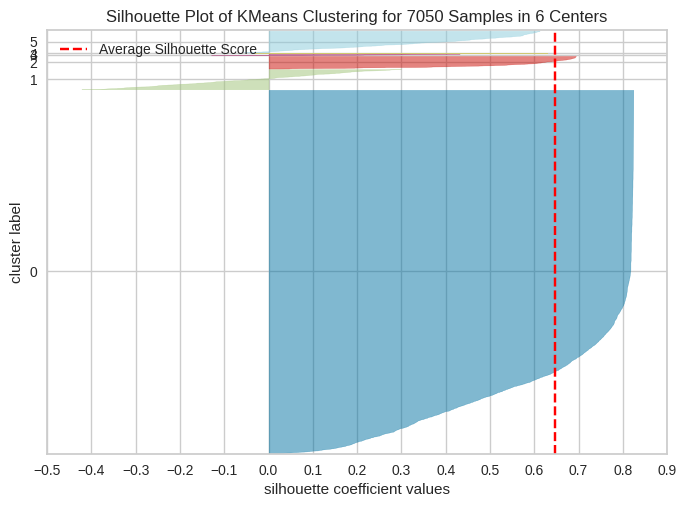

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


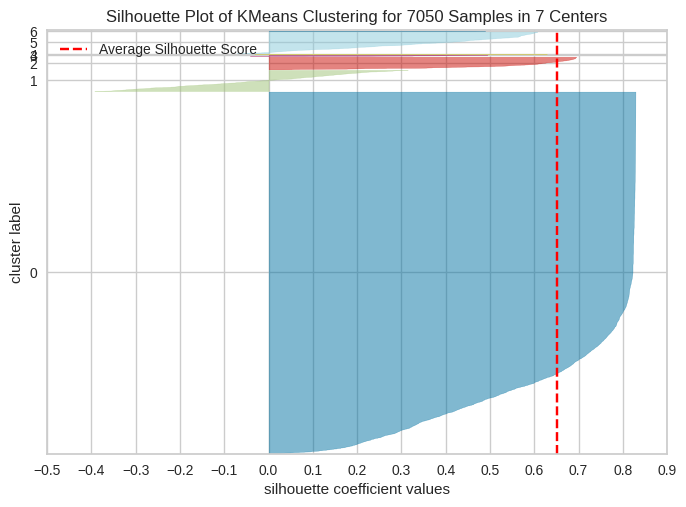

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


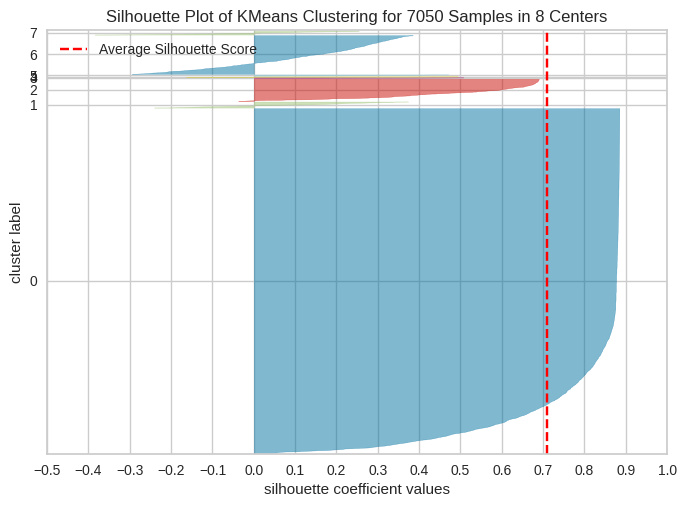

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


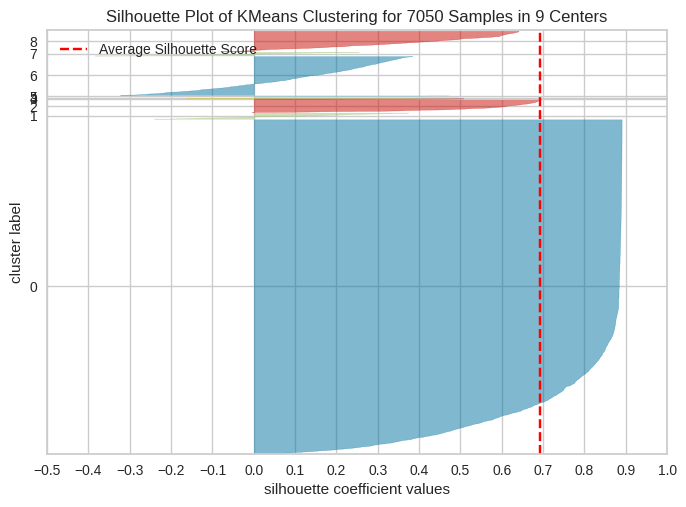

In [ ]:
for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(df_final)
    silhouetteFunction(df_final, kmeans)

### Execução com melhor k

- Melhor valor de K foi 8
- Mostramos para o dataset original (a execução é com o escalonado)

In [7]:
# COLOCA NO df_kmeans OS CLUSTERS
df_kmeans = data.copy()
kmeans = KMeans(n_clusters = 8, random_state=42, n_init='auto')
y_kmeans = kmeans.fit_predict(df_final)
df_kmeans['cluster']=y_kmeans
df_kmeans

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
0,529,512,262,432,92,3,1,1,0,6
1,150,0,0,150,0,0,0,0,0,0
2,227,236,57,204,21,1,1,0,0,0
3,111,0,0,111,0,0,0,0,0,0
4,213,0,0,204,9,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
7045,89,0,0,89,0,0,0,0,0,0
7046,16,0,0,14,1,0,1,0,0,0
7047,2,0,0,1,1,0,0,0,0,0
7048,351,12,22,349,2,0,0,0,0,0


### Cálculo dos Scores para o melhor K

#### Silhouette Score

In [8]:
silhouette_score_kmeans = silhouette_score(df_final, y_kmeans, random_state=42)
silhouette_score_kmeans

0.7082222163756745

#### Davies-Bouldin Score

In [9]:
davies_bouldin_score_kmeans = davies_bouldin_score(df_final, y_kmeans)
davies_bouldin_score_kmeans

1.0719268530671984

#### Calinski and Harabasz Score

In [10]:
calinski_harabasz_score_kmeans = calinski_harabasz_score(df_final, y_kmeans)
calinski_harabasz_score_kmeans

2165.0169916252203

## Agrupamento Hierárquico

### Avaliação do número de clusters

- Função auxiliar

In [11]:
class AgglomerativeClusteringWrapper (AgglomerativeClustering):
    def predict(self,X):
        return self.labels_.astype(int)

#### Dendrograma

In [ ]:
threshold_value = 55

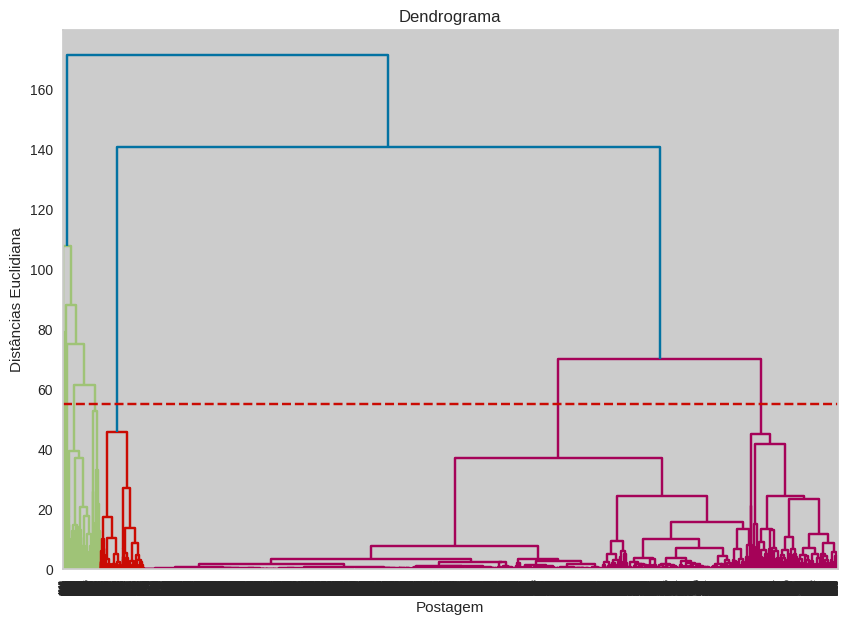

In [ ]:
plt.figure(figsize=(10, 7))
Z = linkage(df_final, 'ward')
dendrogram(Z)
plt.title('Dendrograma')
plt.axhline(y=threshold_value, color='r', linestyle='--')  # Escolha o valor de corte
plt.xlabel('Postagem')
plt.ylabel('Distâncias Euclidiana')
plt.show()

#### Silhouette Score

In [ ]:
scores_values_silhouette = []
for i in range(2, 15):
    Agg = AgglomerativeClusteringWrapper(n_clusters = i, linkage='ward')
    y_agg = Agg.fit_predict(df_final)
    score = silhouette_score(df_final, y_agg, random_state=42)
    scores_values_silhouette.append(score)

- Gráfico de comparação dos Silhouette Scores

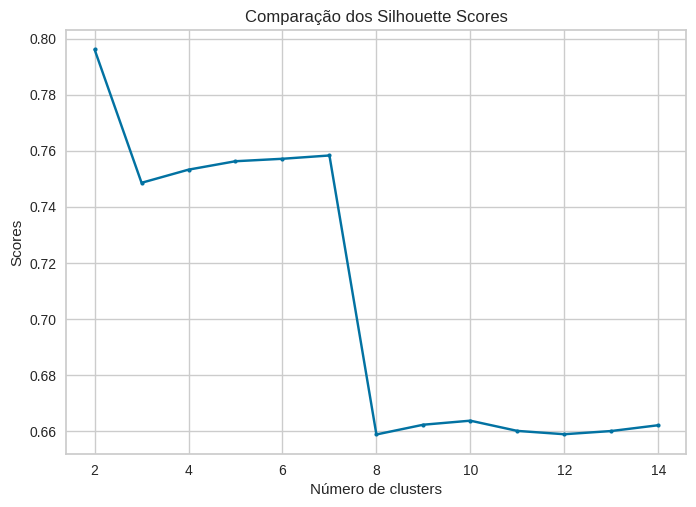

In [ ]:
plt.plot(range(2, 15), scores_values_silhouette, 'bo-', markersize=3)
plt.title('Comparação dos Silhouette Scores')
plt.xlabel('Número de clusters')
plt.ylabel('Scores')
plt.show()

#### Silhouette Visualizer

- Teste para valores distintos de clusters

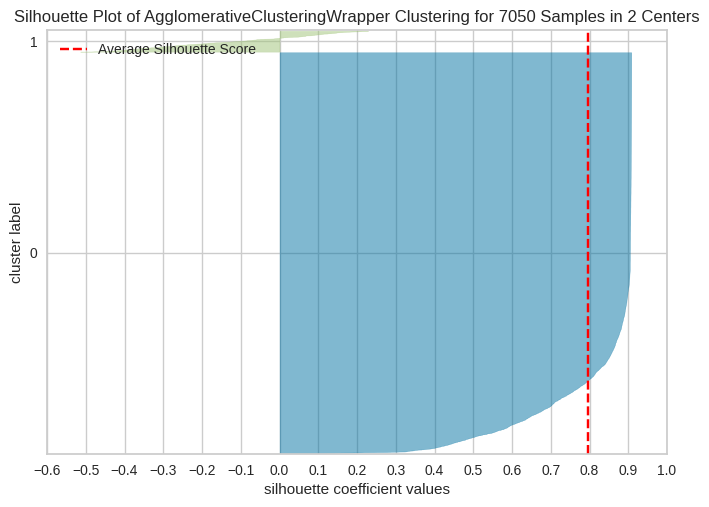

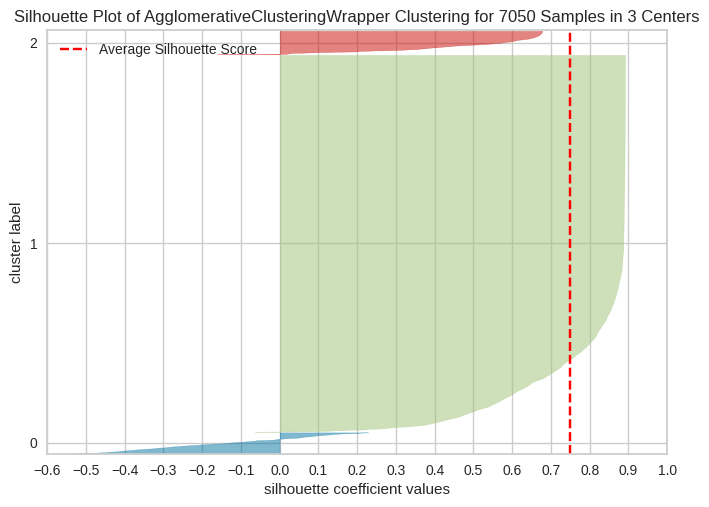

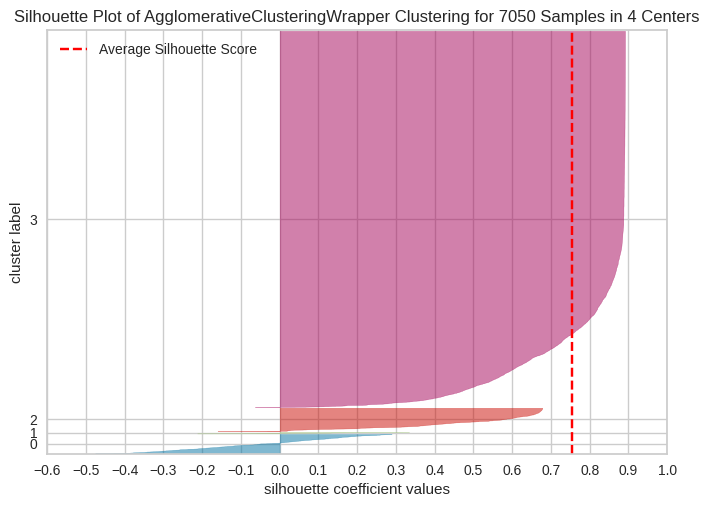

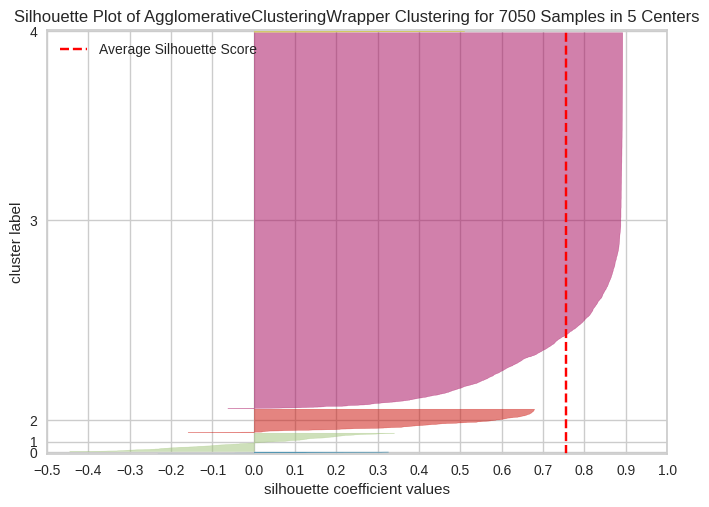

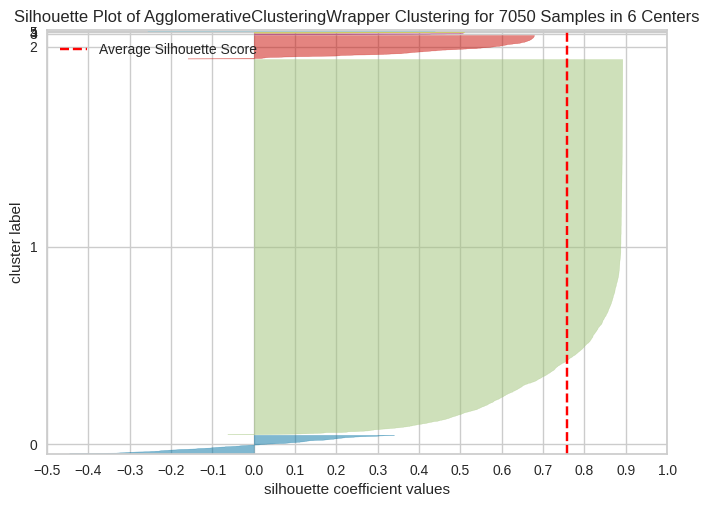

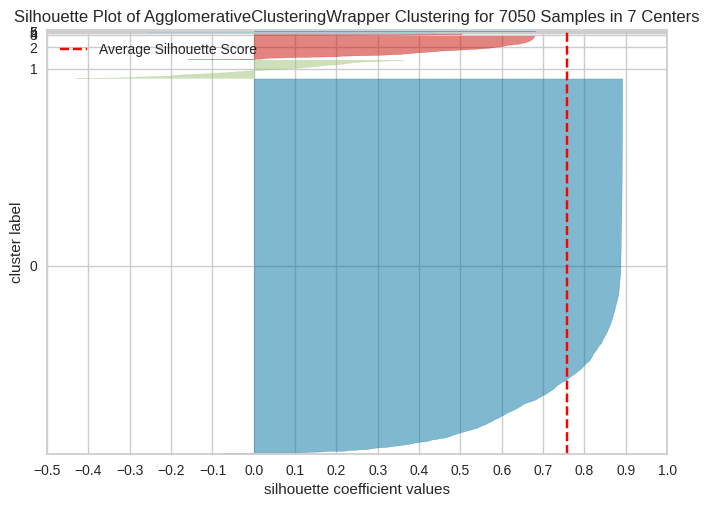

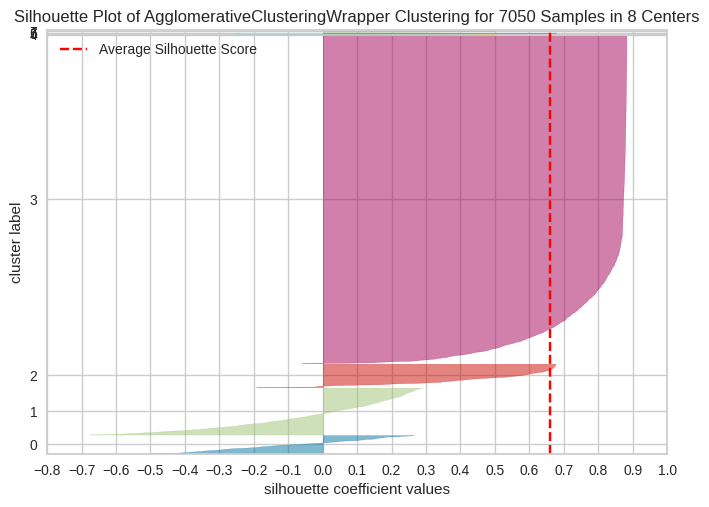

In [ ]:
for i in range(2, 9):
    Agg = AgglomerativeClusteringWrapper(n_clusters=i, linkage='ward')
    Agg.fit(df_final)
    silhouetteFunction(df_final, Agg)

### Execução com o melhor número de clusters

- Melhor número de clusters foi 7

In [12]:
df_agg = data.copy()
Agg = AgglomerativeClusteringWrapper(n_clusters=7, linkage='ward')
y_agg = Agg.fit_predict(df_final)
df_agg['cluster']=y_agg
df_agg

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
0,529,512,262,432,92,3,1,1,0,0
1,150,0,0,150,0,0,0,0,0,0
2,227,236,57,204,21,1,1,0,0,0
3,111,0,0,111,0,0,0,0,0,0
4,213,0,0,204,9,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
7045,89,0,0,89,0,0,0,0,0,0
7046,16,0,0,14,1,0,1,0,0,0
7047,2,0,0,1,1,0,0,0,0,0
7048,351,12,22,349,2,0,0,0,0,0


### Cálculo dos Scores para o melhor número de clusters

#### Silhouette Score

In [13]:
silhouette_score_agg = silhouette_score(df_final, y_agg, random_state=42)
silhouette_score_agg

0.7583148061163044

#### Davies-Bouldin Score

In [14]:
davies_bouldin_score_agg = davies_bouldin_score(df_final, y_agg)
davies_bouldin_score_agg

0.7919573497512543

#### Calinski and Harabasz Score

In [15]:
calinski_harabasz_score_agg = calinski_harabasz_score(df_final, y_agg)
calinski_harabasz_score_agg

2031.5831309907835

## DBSCAN

#### Parâmetros para teste

In [18]:
# Definir os hiperparâmetros que queremos testar
eps_values = np.linspace(0.1, 1.0, 20) # raio entre pontos
min_samples_values = range(2, 10) # mínimo de amostras

### Retorno da função

In [19]:
best_score = -1
best_hparams = None
y_dbs = None

### Execução do DBScan escolhendo os melhores hiperparâmetros

In [20]:
for eps in eps_values:
    for min_samples in min_samples_values:
        # Aplicar DBSCAN
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(df_final)
    if len(set(labels)) > 1:
        score = silhouette_score(df_final, labels)
        if score > best_score:
            best_score = score
            best_hparams = {'eps': eps, 'min_samples': min_samples}
            y_dbs = labels

### Apresentação dos melhores hiperparâmetros do DBScan

In [21]:
n_clusters = len(set(y_dbs))
print(f"Número de clusters: {n_clusters}")
print(f"Melhores Hiperparâmetros: {best_hparams}")
print(f"Melhor Silhouette Score: {best_score}")

Número de clusters: 3
Melhores Hiperparâmetros: {'eps': 1.0, 'min_samples': 9}
Melhor Silhouette Score: 0.5139514307267232


### Aplicação do PCA para escolha dos melhores hiperparâmetros

In [22]:
labels_list = []
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=7)
    labels = db.fit_predict(df_final)
    labels_list.append(labels)

#### PCA 2D

In [28]:
pca_dbs2d = PCA(n_components=2)
df_pca2d = pca_dbs2d.fit_transform(df_final)

Valor do epsilon: 0.1
Número de clusters: 17


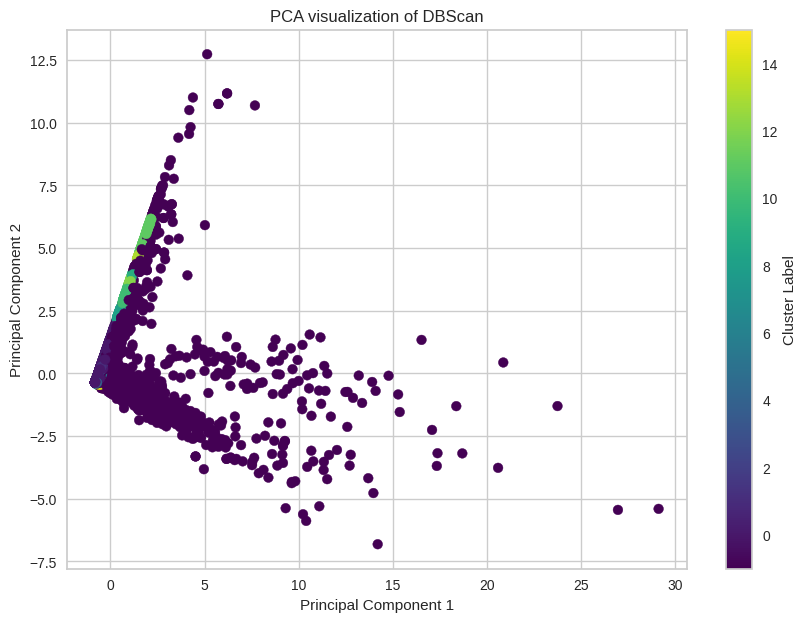

Valor do epsilon: 0.1473684210526316
Número de clusters: 8


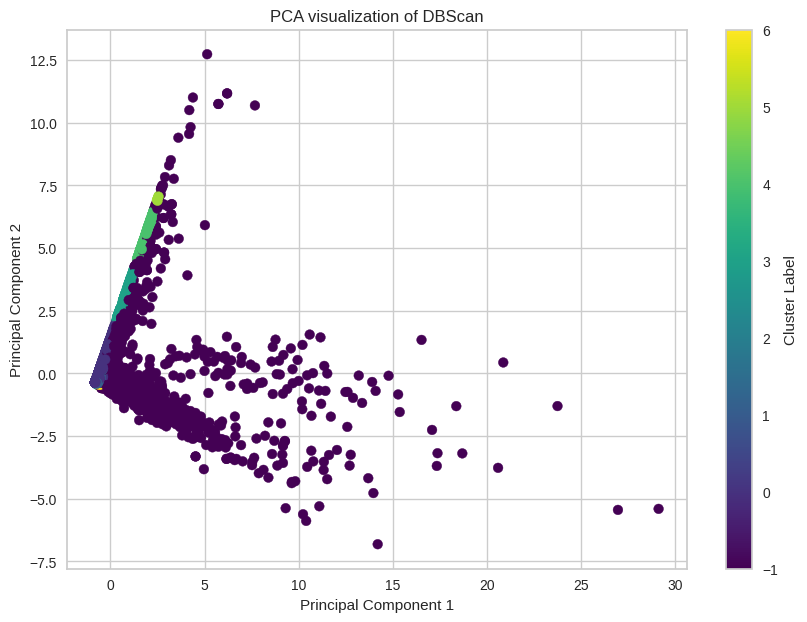

Valor do epsilon: 0.19473684210526315
Número de clusters: 9


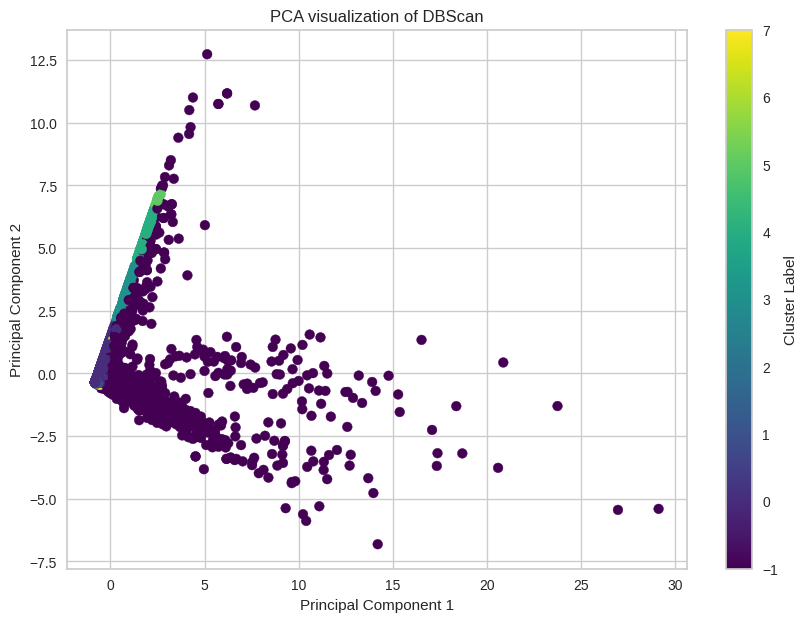

Valor do epsilon: 0.24210526315789474
Número de clusters: 8


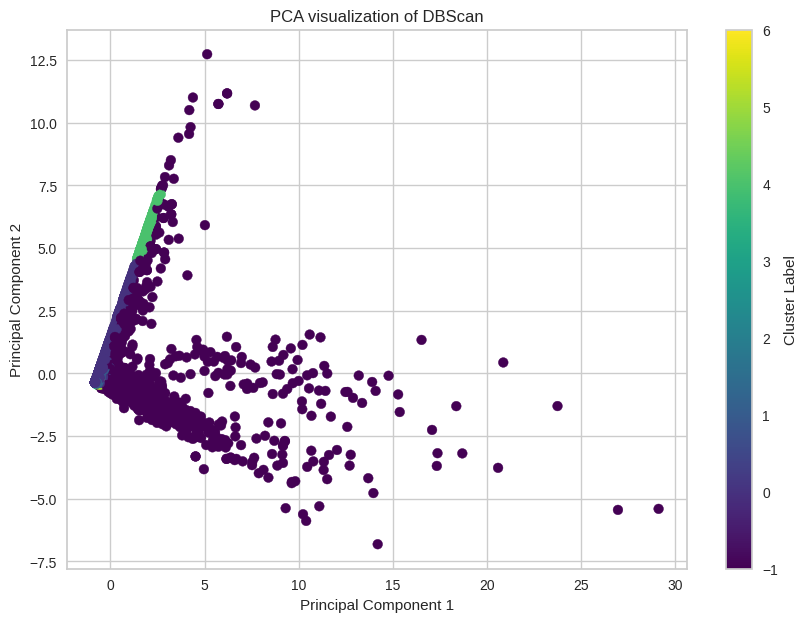

Valor do epsilon: 0.2894736842105263
Número de clusters: 6


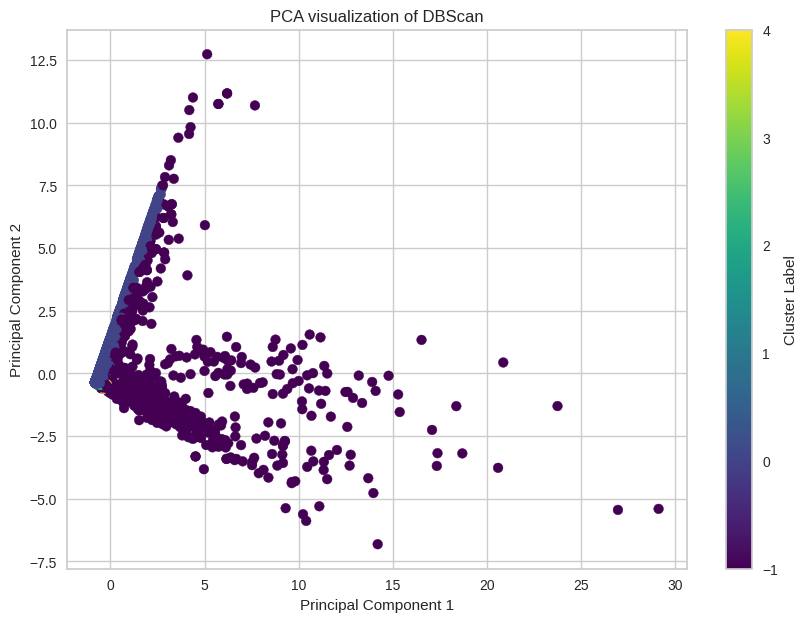

Valor do epsilon: 0.33684210526315794
Número de clusters: 6


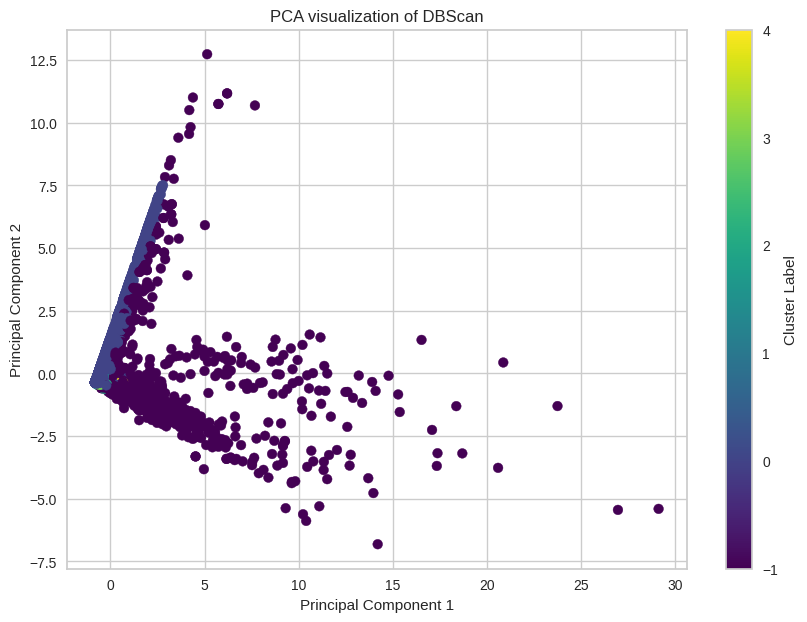

Valor do epsilon: 0.38421052631578945
Número de clusters: 7


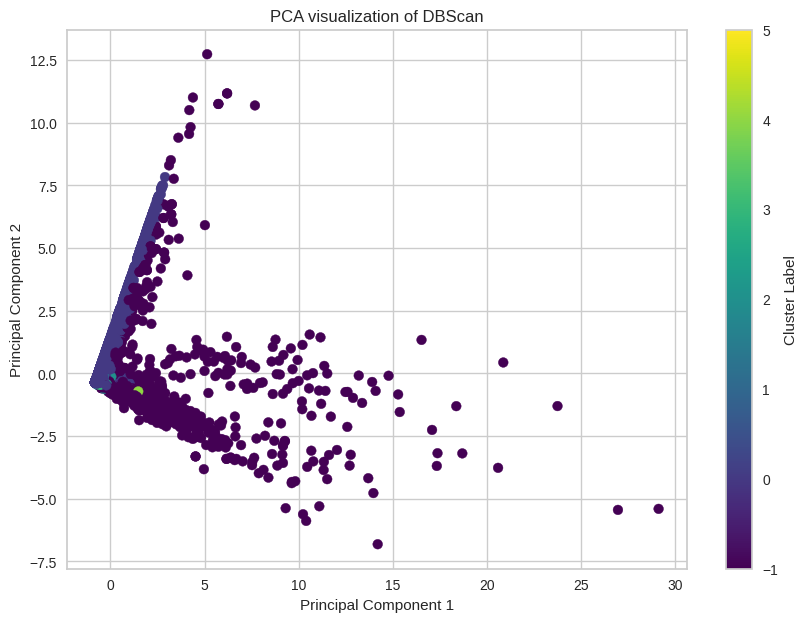

Valor do epsilon: 0.43157894736842106
Número de clusters: 6


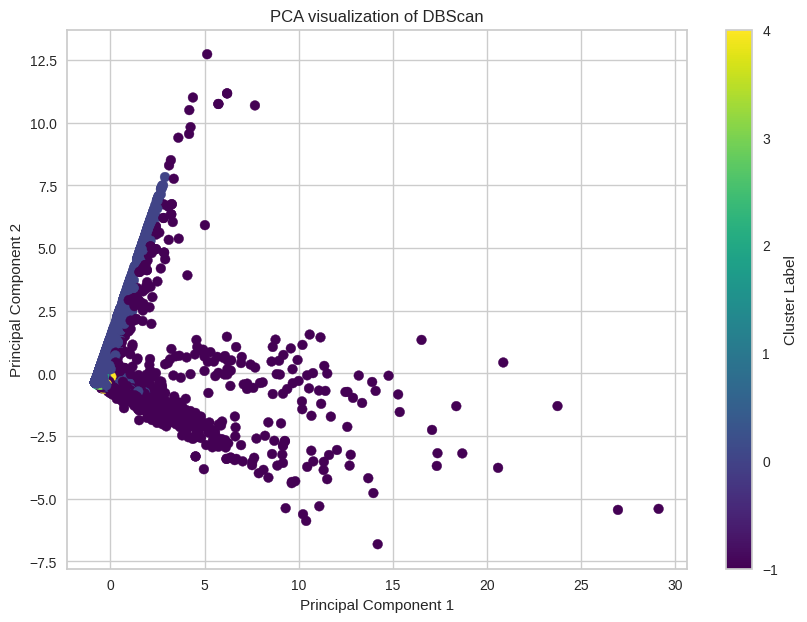

Valor do epsilon: 0.4789473684210527
Número de clusters: 8


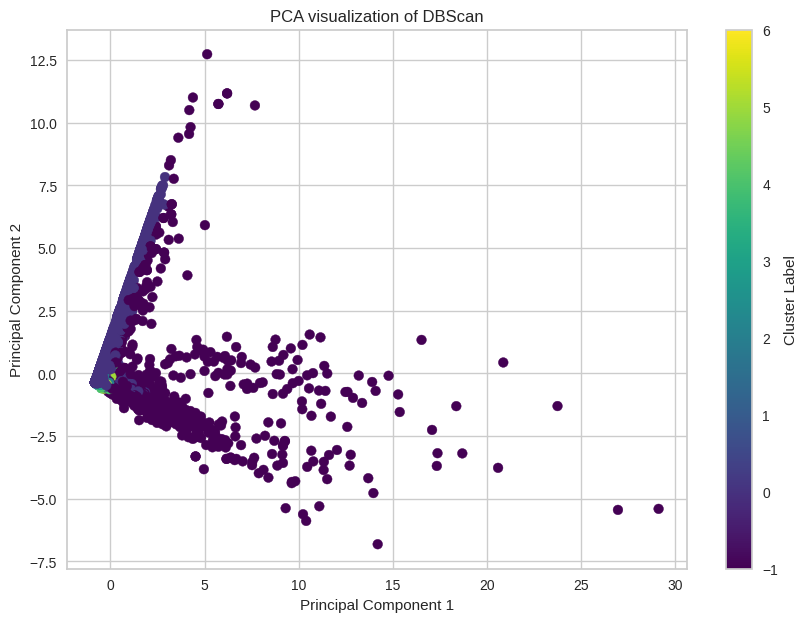

Valor do epsilon: 0.5263157894736842
Número de clusters: 10


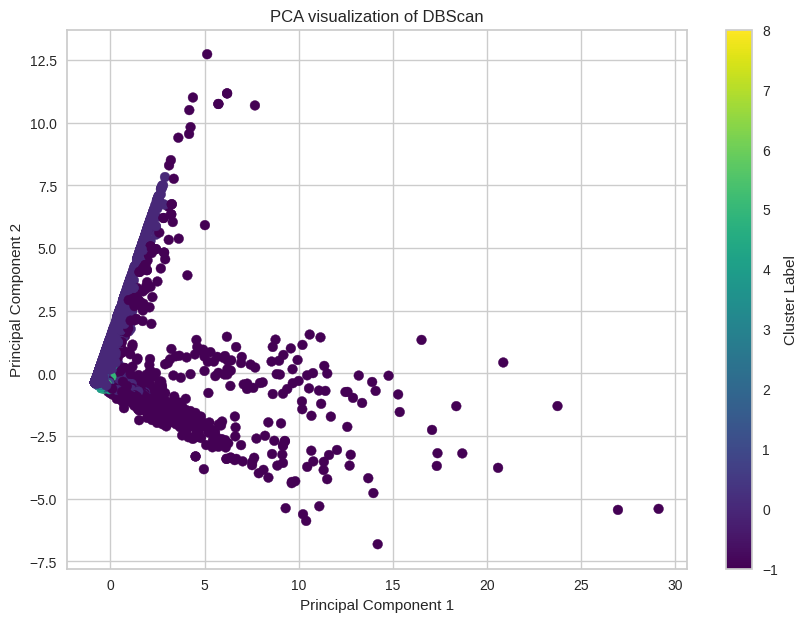

Valor do epsilon: 0.5736842105263158
Número de clusters: 9


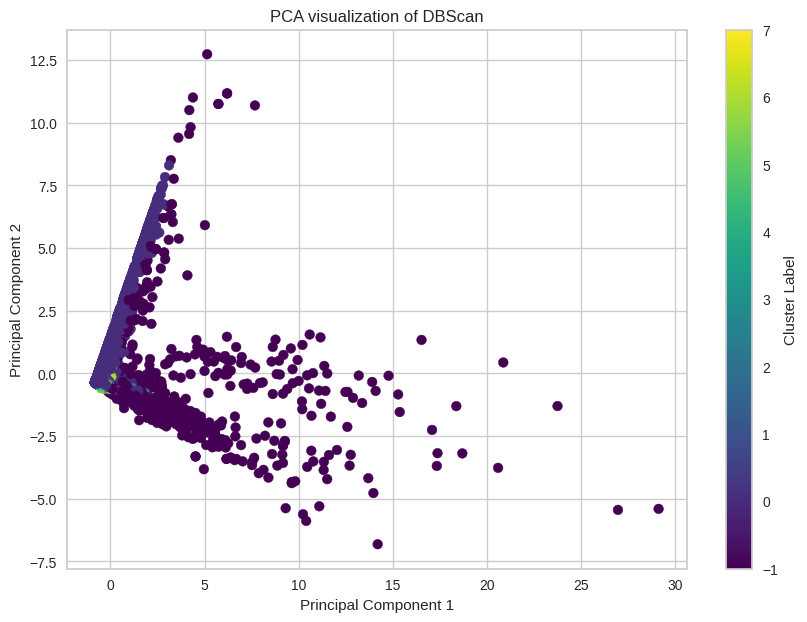

Valor do epsilon: 0.6210526315789474
Número de clusters: 8


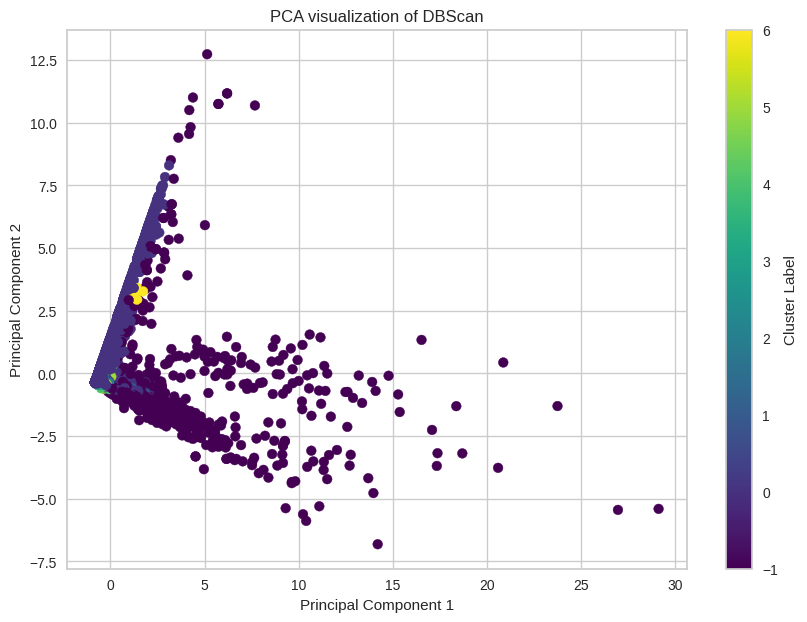

Valor do epsilon: 0.6684210526315789
Número de clusters: 5


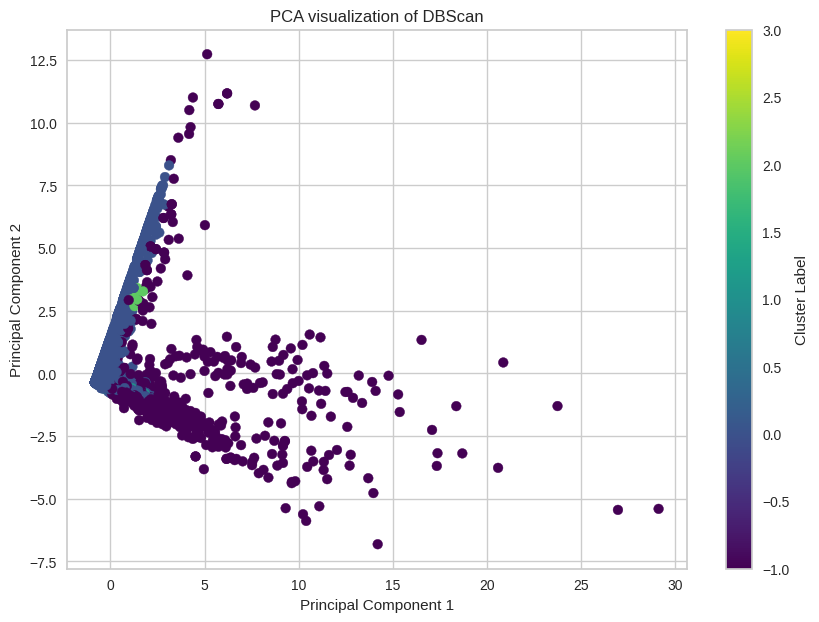

Valor do epsilon: 0.7157894736842105
Número de clusters: 4


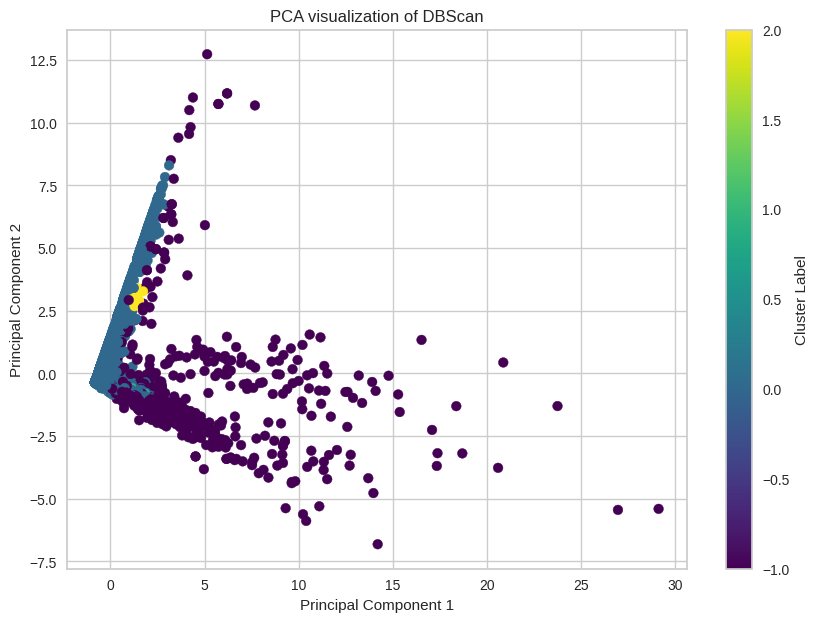

Valor do epsilon: 0.7631578947368421
Número de clusters: 3


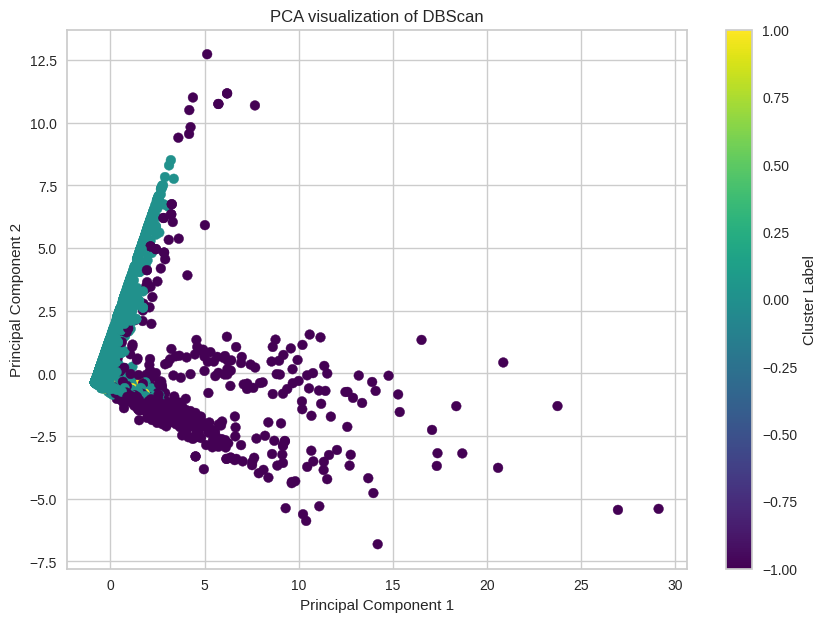

Valor do epsilon: 0.8105263157894737
Número de clusters: 3


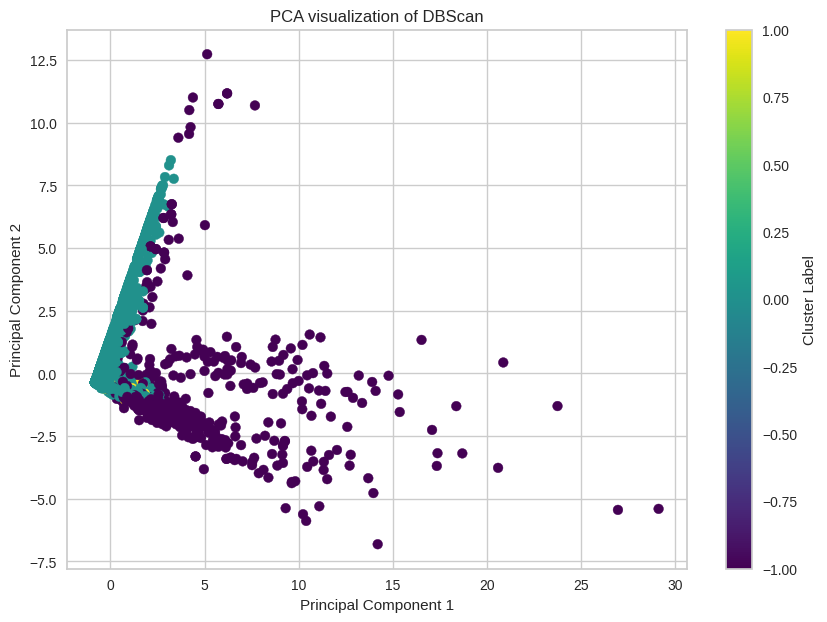

Valor do epsilon: 0.8578947368421053
Número de clusters: 3


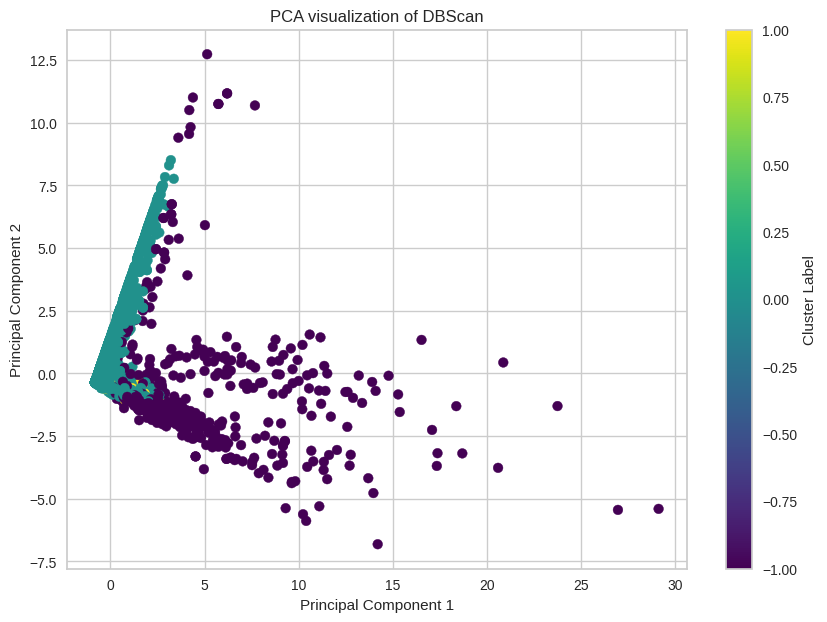

Valor do epsilon: 0.9052631578947369
Número de clusters: 3


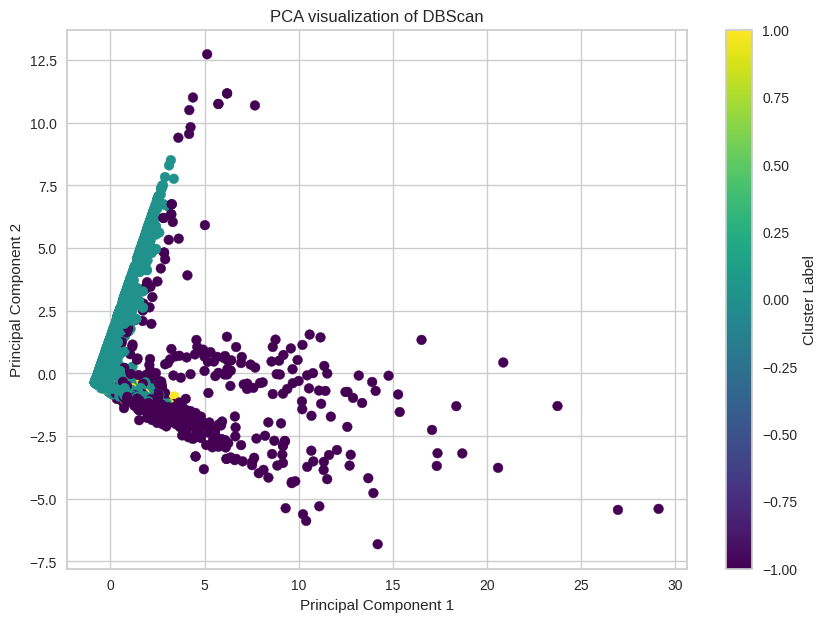

Valor do epsilon: 0.9526315789473684
Número de clusters: 3


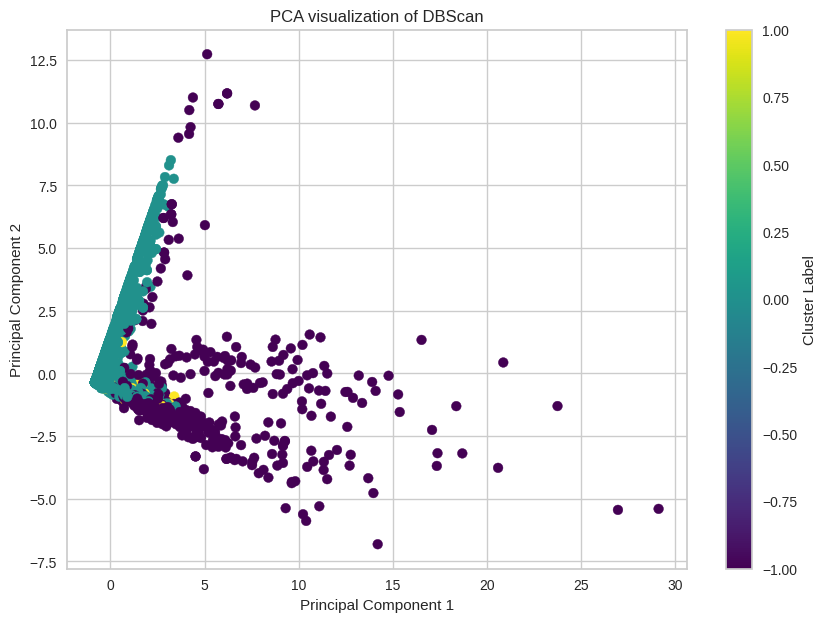

Valor do epsilon: 1.0
Número de clusters: 3


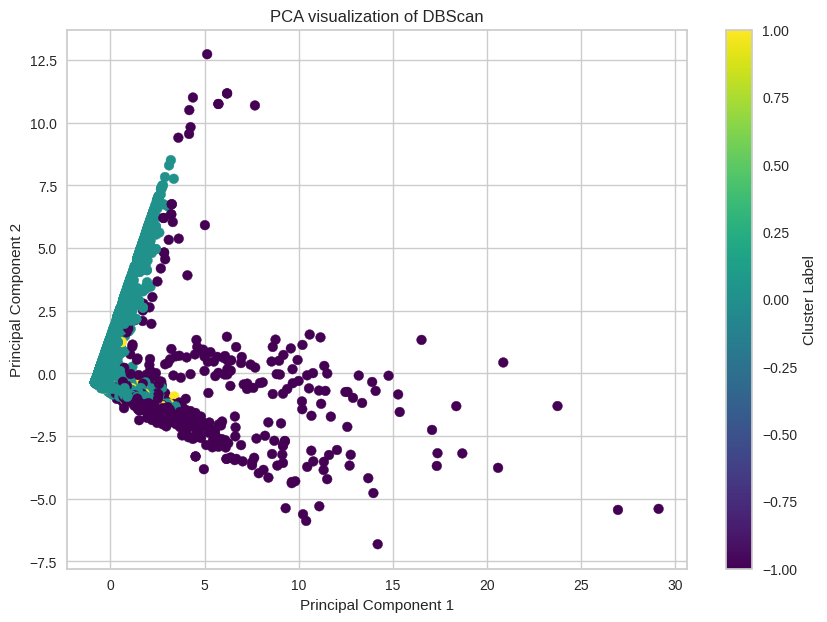

In [ ]:
for i in range(len(labels_list)):
    eps = eps_values[i]
    labels = labels_list[i]
    print(f"Valor do epsilon: {eps}")
    print(f"Número de clusters: {len(np.unique(labels))}")
    plt.figure(figsize=(10, 7))
    plt.scatter(df_pca2d[:, 0], df_pca2d[:, 1], c=labels, cmap='viridis')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(f"PCA visualization of DBScan")
    plt.colorbar(label='Cluster Label')
    plt.show()

#### PCA 3D

In [29]:
pca_dbs3d = PCA(n_components=3)
df_pca3d = pca_dbs3d.fit_transform(df_final)

Valor do epsilon: 0.1
Número de clusters: 19


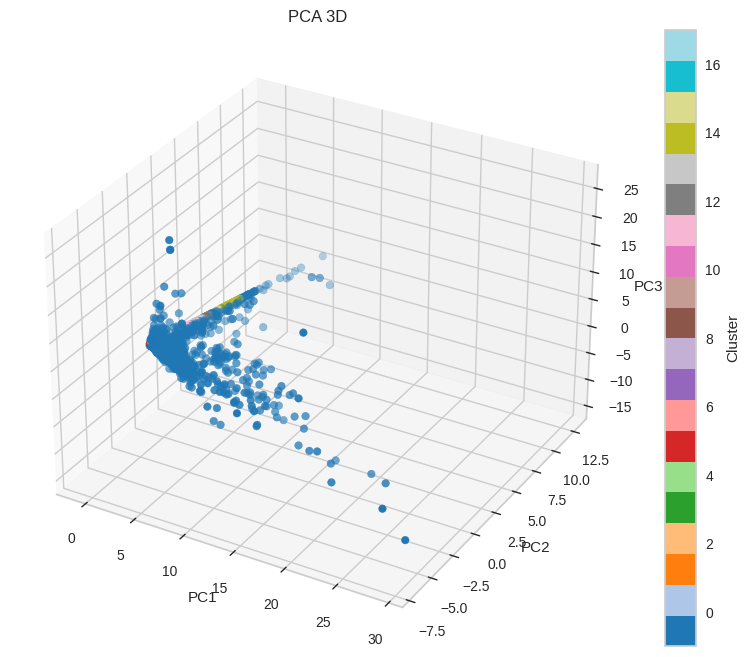

Valor do epsilon: 0.1473684210526316
Número de clusters: 9


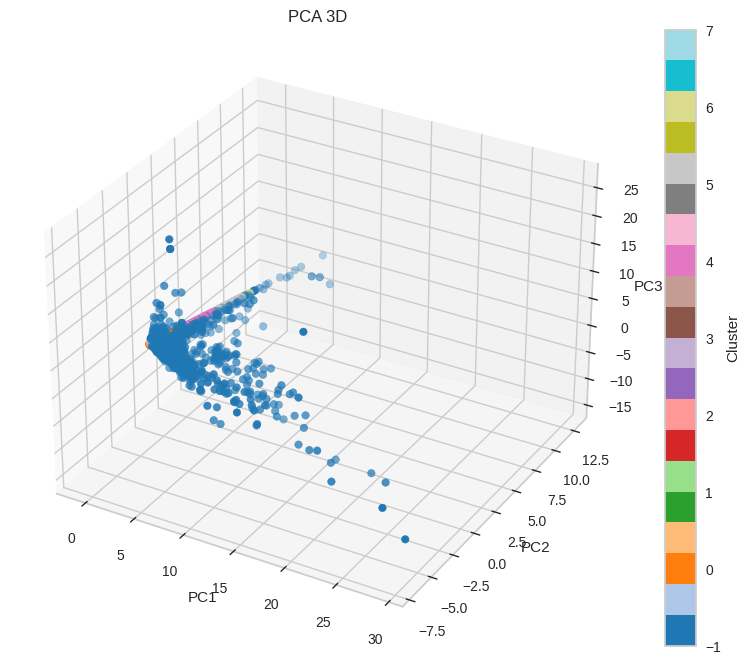

Valor do epsilon: 0.19473684210526315
Número de clusters: 8


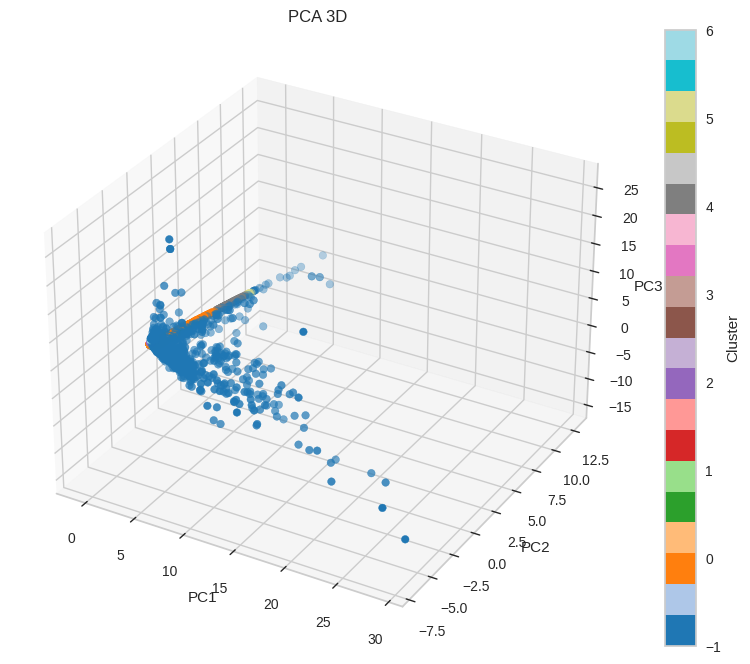

Valor do epsilon: 0.24210526315789474
Número de clusters: 10


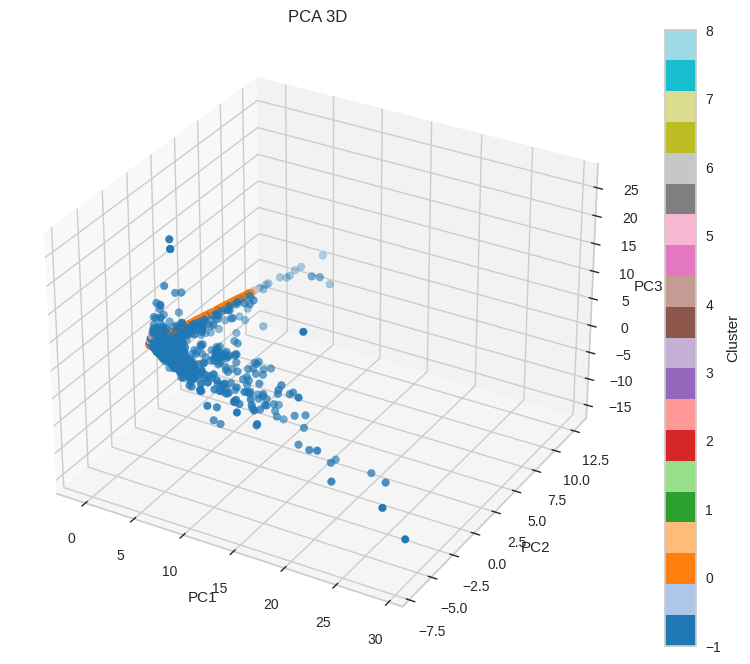

Valor do epsilon: 0.2894736842105263
Número de clusters: 7


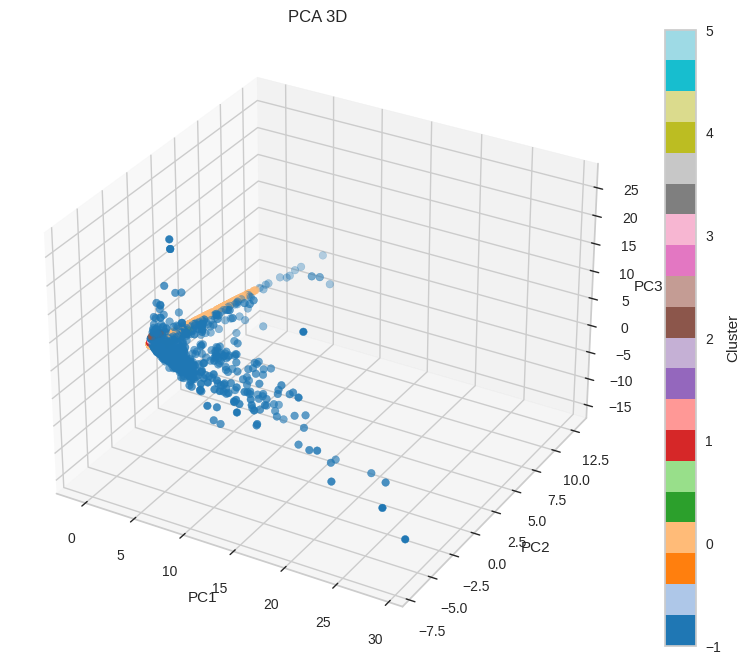

Valor do epsilon: 0.33684210526315794
Número de clusters: 7


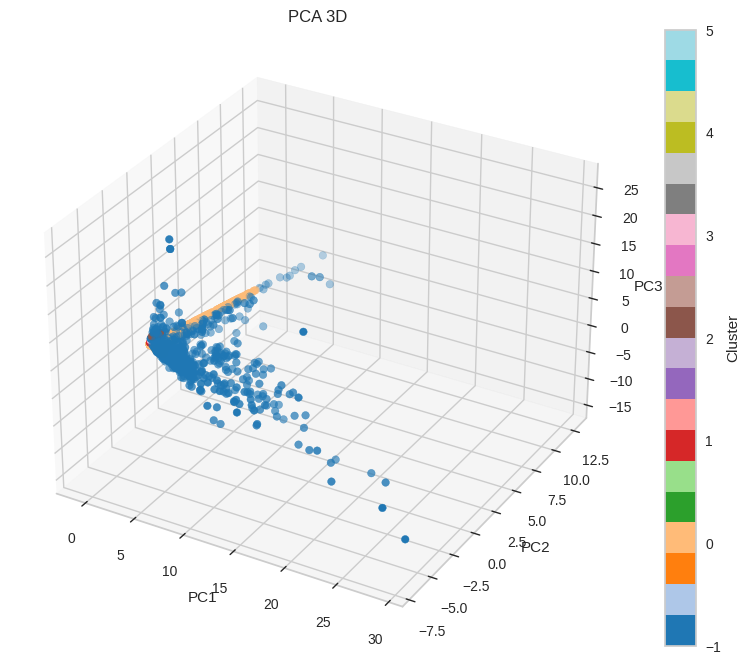

Valor do epsilon: 0.38421052631578945
Número de clusters: 7


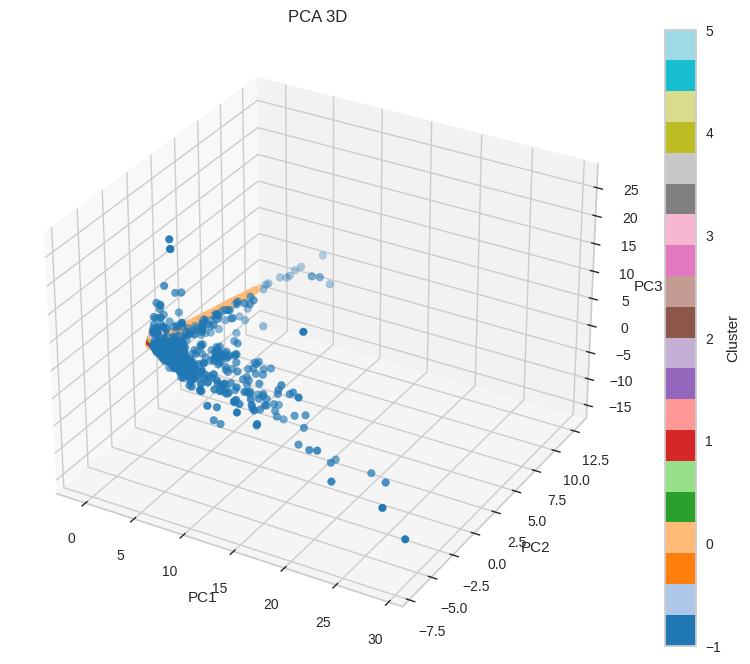

Valor do epsilon: 0.43157894736842106
Número de clusters: 9


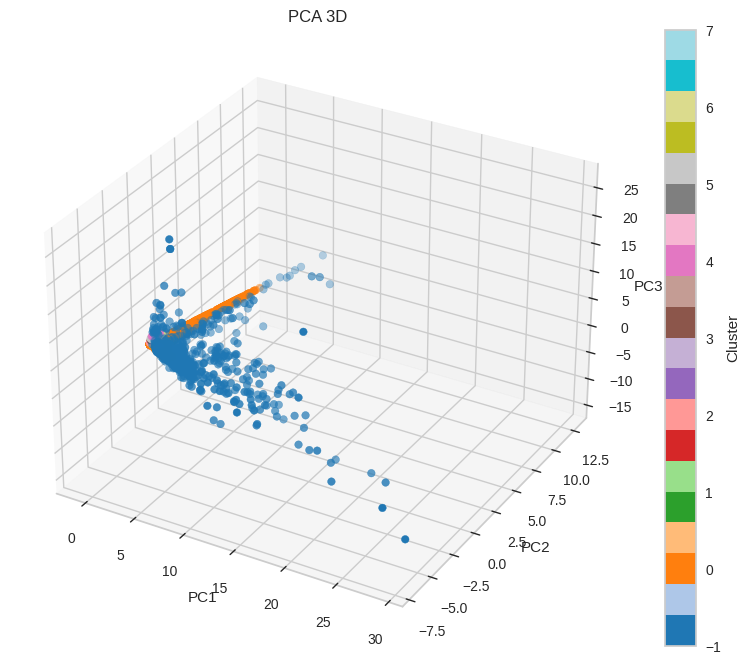

Valor do epsilon: 0.4789473684210527
Número de clusters: 9


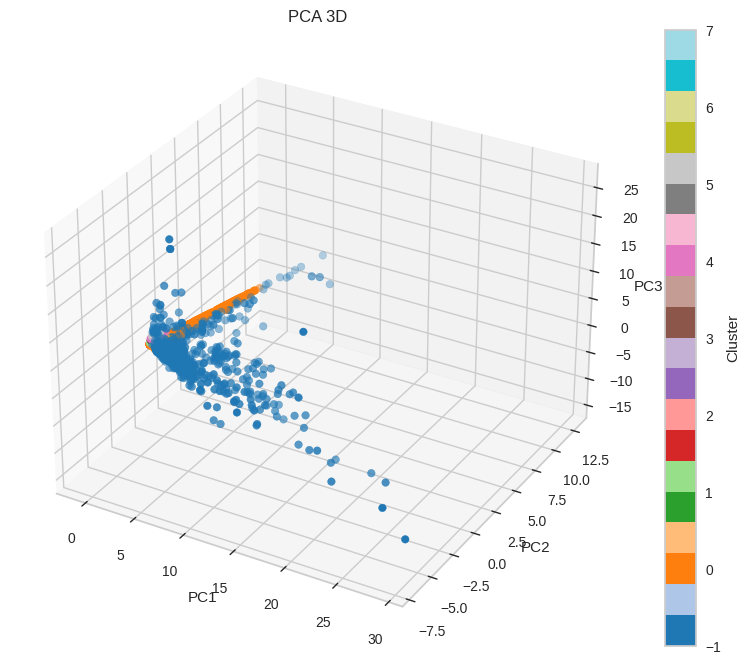

Valor do epsilon: 0.5263157894736842
Número de clusters: 10


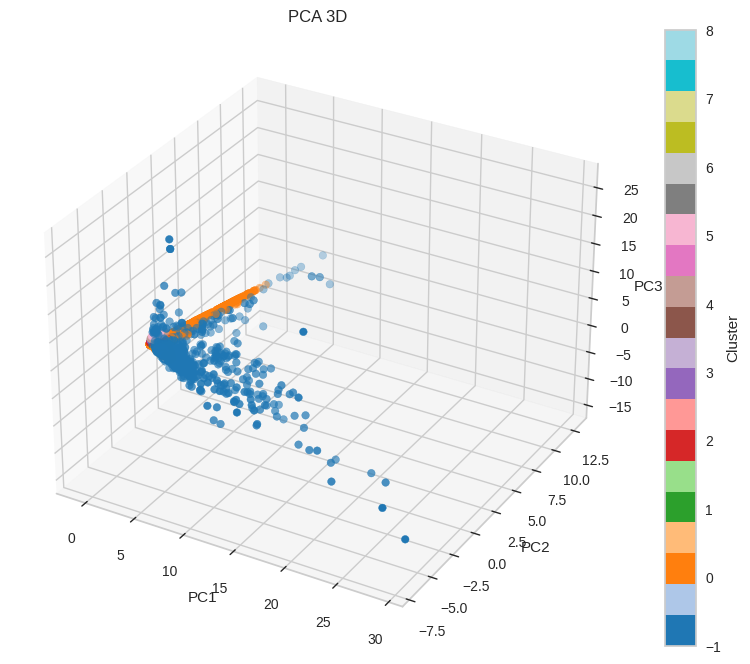

Valor do epsilon: 0.5736842105263158
Número de clusters: 10


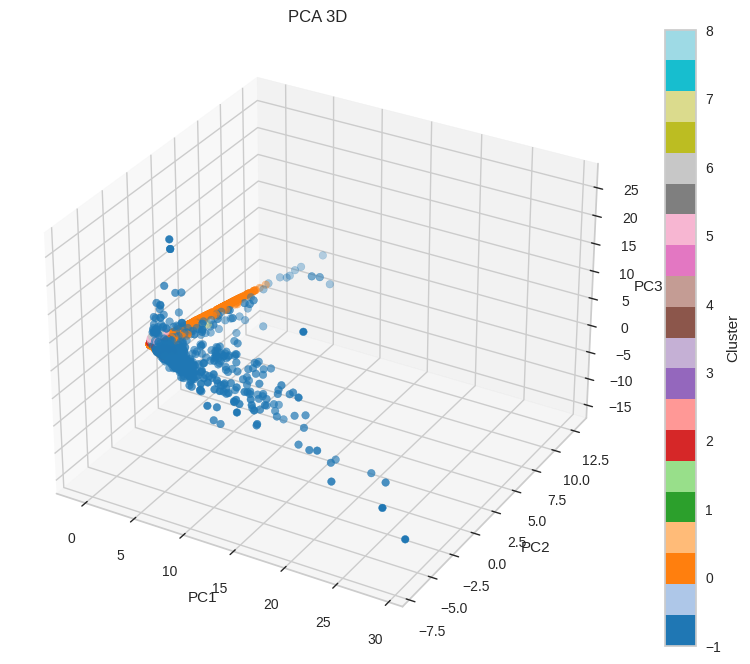

Valor do epsilon: 0.6210526315789474
Número de clusters: 10


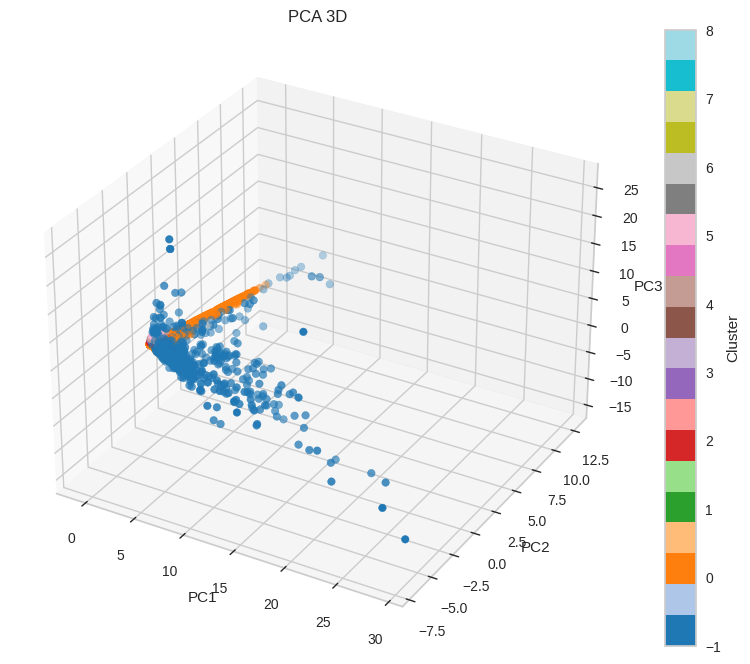

Valor do epsilon: 0.6684210526315789
Número de clusters: 6


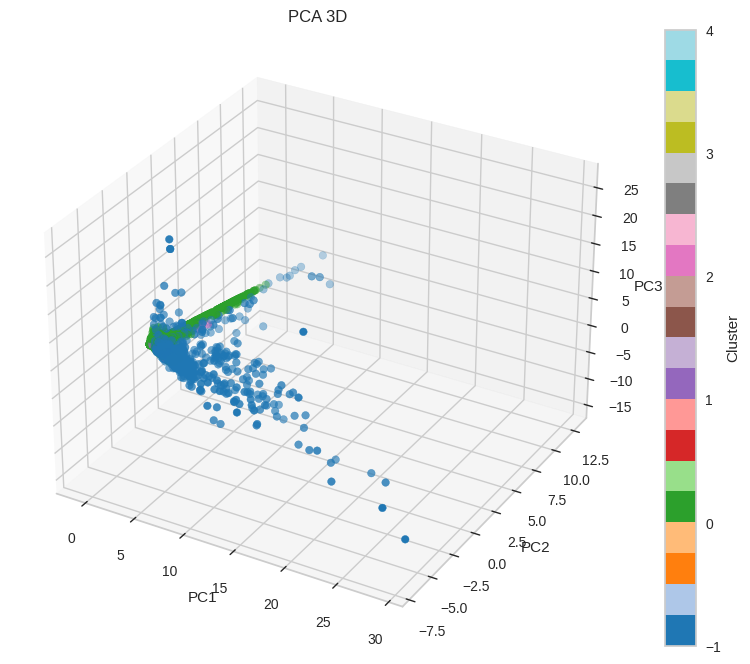

Valor do epsilon: 0.7157894736842105
Número de clusters: 4


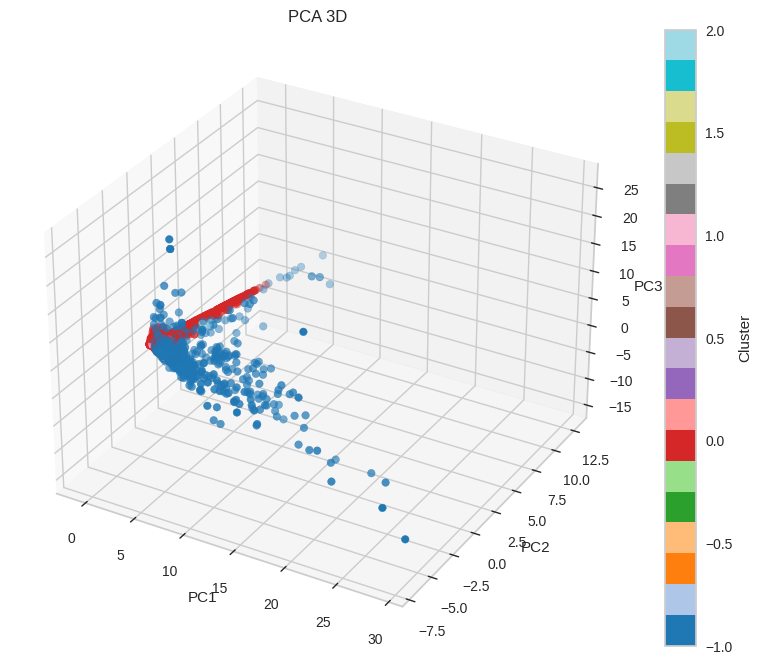

Valor do epsilon: 0.7631578947368421
Número de clusters: 3


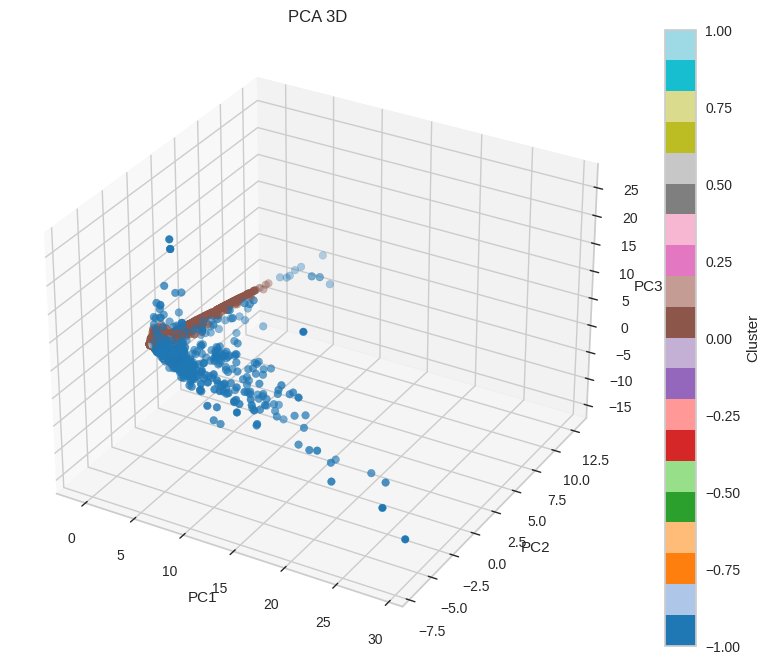

Valor do epsilon: 0.8105263157894737
Número de clusters: 3


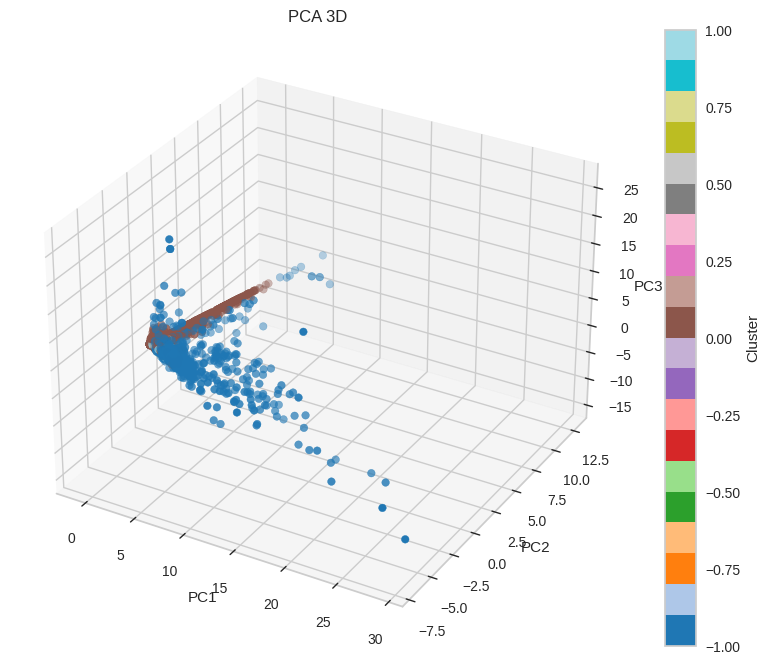

Valor do epsilon: 0.8578947368421053
Número de clusters: 3


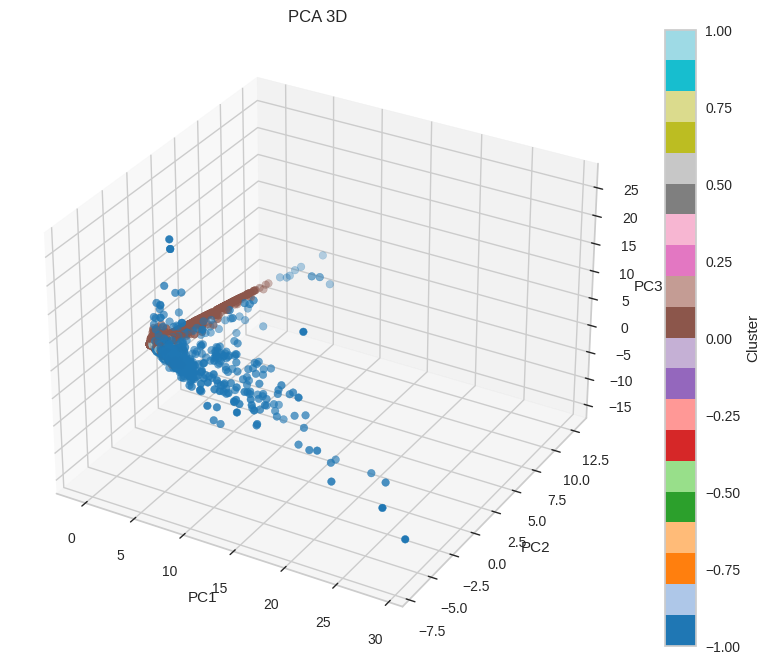

Valor do epsilon: 0.9052631578947369
Número de clusters: 3


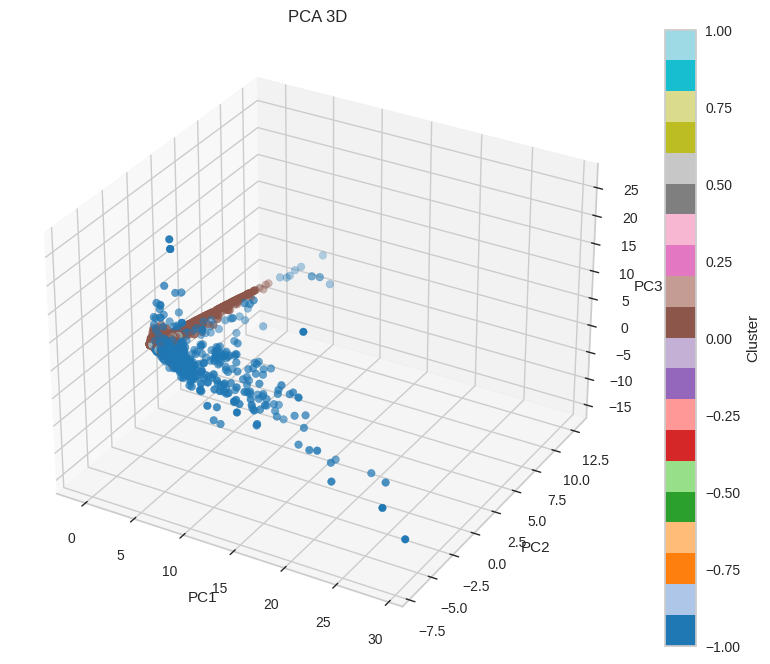

Valor do epsilon: 0.9526315789473684
Número de clusters: 3


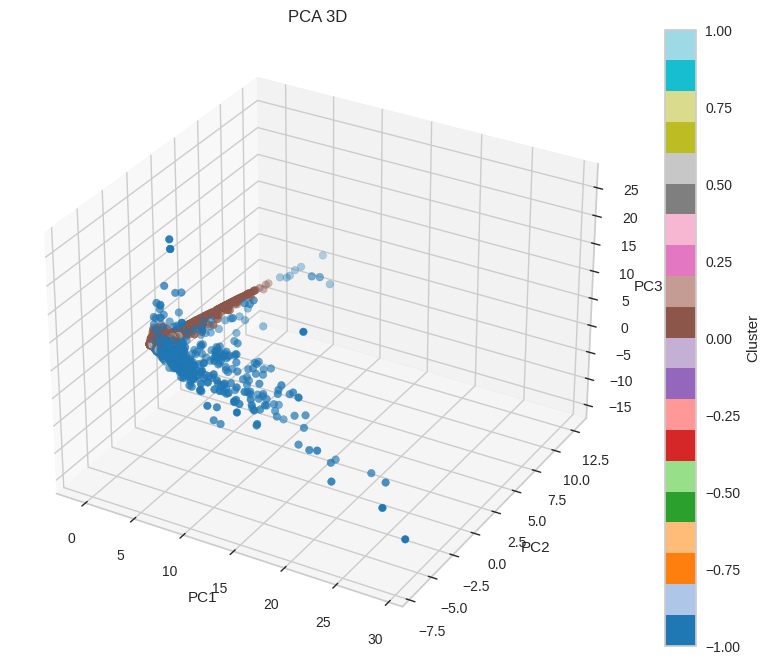

Valor do epsilon: 1.0
Número de clusters: 3


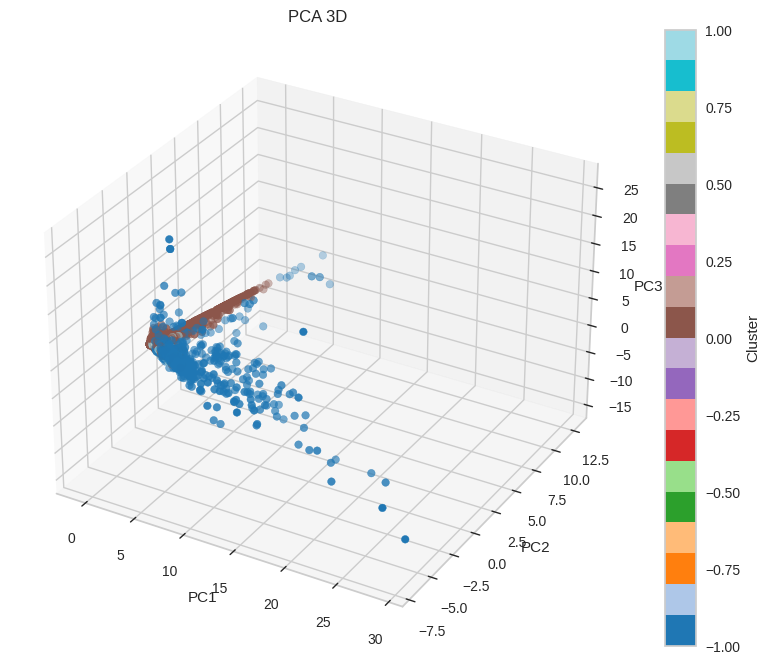

In [26]:
for i in range(len(labels_list)):
  eps = eps_values[i]
  labels = labels_list[i]
  print(f"Valor do epsilon: {eps}")
  print(f"Número de clusters: {len(np.unique(labels))}")
  fig = plt.figure(figsize=(10, 8))

  ax = fig.add_subplot(111, projection='3d')

  # Use cores para diferenciar os clusters, se você tiver essa informação
  scatter = ax.scatter(df_pca3d[:,0], df_pca3d[:,1], df_pca3d[:,2], c=labels, cmap='tab20', s=30)

  # Adicionar títulos e labels
  ax.set_title('PCA 3D')
  ax.set_xlabel('PC1')
  ax.set_ylabel('PC2')
  ax.set_zlabel('PC3')

    # Adicionar uma barra de cores, se estiver usando clusters
  cbar = plt.colorbar(scatter)
  cbar.set_label('Cluster')

  plt.show()

### DataFrame com labels

- eps: 1.0
- min_samples: 9
- número de clusters: 3

In [68]:
df_dbs = data.copy()
df_dbs['cluster']=y_dbs
df_dbs

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
0,529,512,262,432,92,3,1,1,0,0
1,150,0,0,150,0,0,0,0,0,0
2,227,236,57,204,21,1,1,0,0,0
3,111,0,0,111,0,0,0,0,0,0
4,213,0,0,204,9,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
7045,89,0,0,89,0,0,0,0,0,0
7046,16,0,0,14,1,0,1,0,0,0
7047,2,0,0,1,1,0,0,0,0,0
7048,351,12,22,349,2,0,0,0,0,0


### Cálculo dos Scores para o melhor número de clusters

- O número de clusters escolhido foi 3

#### Silhouette Score

In [30]:
silhouette_score_dbs = silhouette_score(df_final, y_dbs, random_state=42)
silhouette_score_dbs

0.5139514307267232

#### Davies-Bouldin Score

In [31]:
davies_bouldin_score_dbs = davies_bouldin_score(df_final, y_dbs)
davies_bouldin_score_dbs

1.862707871783516

#### Calinski and Harabasz Score

In [32]:
calinski_harabasz_score_dbs = calinski_harabasz_score(df_final, y_dbs)
calinski_harabasz_score_dbs

994.5032913115613

# Avaliação dos Resultados

- Utilizaremos as métricas: Método do Cotovelo, Silhouette Score, Davies-Bouldin Score e Calinski and Harabasz Score.

In [33]:
results = {
    'Kmeans': {
        'Silhouette Score': silhouette_score_kmeans,
        'Davies-Bouldin Score':davies_bouldin_score_kmeans,
        'Calinski and Harabasz Score':calinski_harabasz_score_kmeans
    },
    'Agglomerative Clustering': {
        'Silhouette Score': silhouette_score_agg,
        'Davies-Bouldin Score':davies_bouldin_score_agg,
        'Calinski and Harabasz Score':calinski_harabasz_score_agg
    },
    'DBScan':{
        'Silhouette Score': silhouette_score_dbs,
        'Davies-Bouldin Score':davies_bouldin_score_dbs,
        'Calinski and Harabasz Score':calinski_harabasz_score_dbs
    }
}
df_results = pd.DataFrame(results)

## Comparação das técnicas por score

Utilizaremos as métricas: Método do Cotovelo, Silhouette Score, Davies-Bouldin Score e Calinski and Harabasz Score.

- Tabela de comparação

In [34]:
df_results.T

,Silhouette Score,Davies-Bouldin Score,Calinski and Harabasz Score
Kmeans,0.708222,1.071927,2165.016992
Agglomerative Clustering,0.758315,0.791957,2031.583131
DBScan,0.513951,1.862708,994.503291


- Gráficos de comparação de métricas

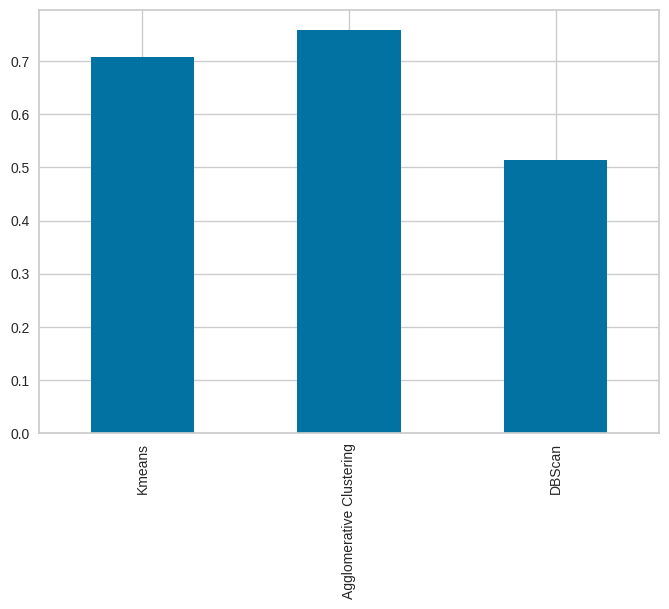

In [35]:
df_results.T['Silhouette Score'].plot.bar();

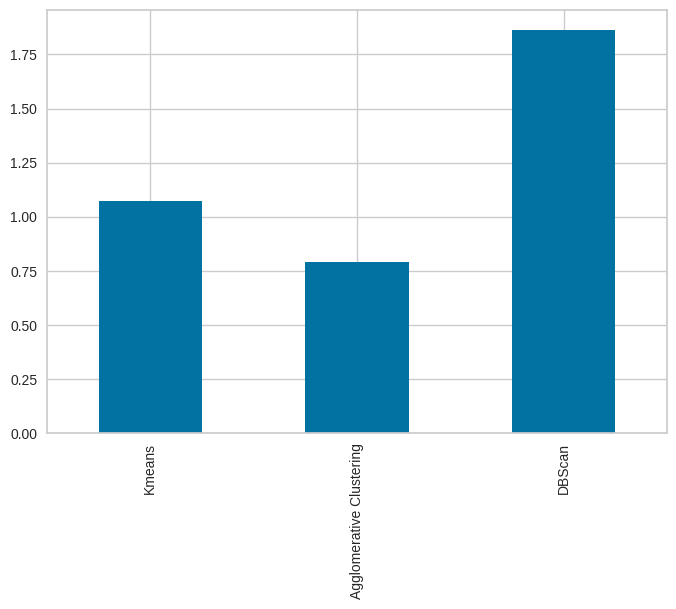

In [36]:
df_results.T['Davies-Bouldin Score'].plot.bar();

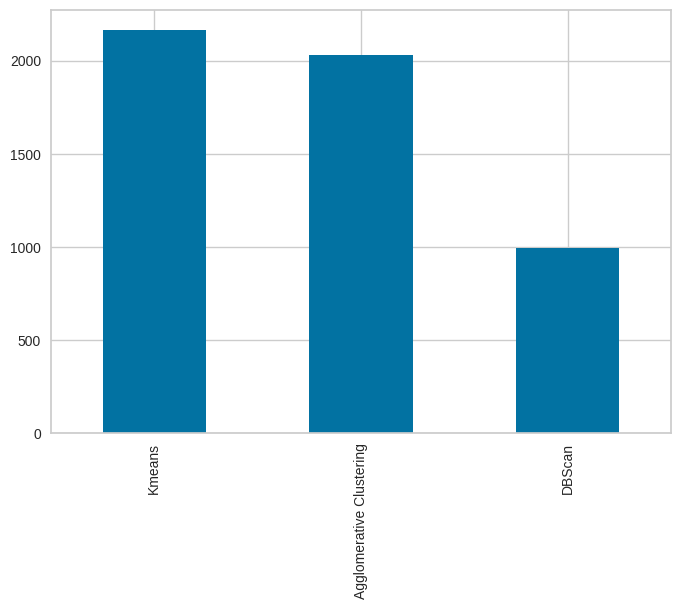

In [37]:
df_results.T['Calinski and Harabasz Score'].plot.bar();

# Apresentação dos Resultados

- Função do Gráfico de dispersão

In [ ]:
def visualizeResultsPCA(tecnica, X, labels):
    plt.figure(figsize=(10, 7))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(f"PCA visualization of {tecnica}")
    plt.colorbar(label='Cluster Label')
    plt.show()

In [ ]:
def visualizeResultsTSNE(tecnica, X, labels):
    # Criando o gráfico
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
    plt.title(f"t-SNE visualization of {tecnica}")
    plt.xlabel('t-SNE feature 1')
    plt.ylabel('t-SNE feature 2')
    plt.colorbar(label='Cluster Label')
    plt.show()

## PCA

In [ ]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_final)

### Kmeans

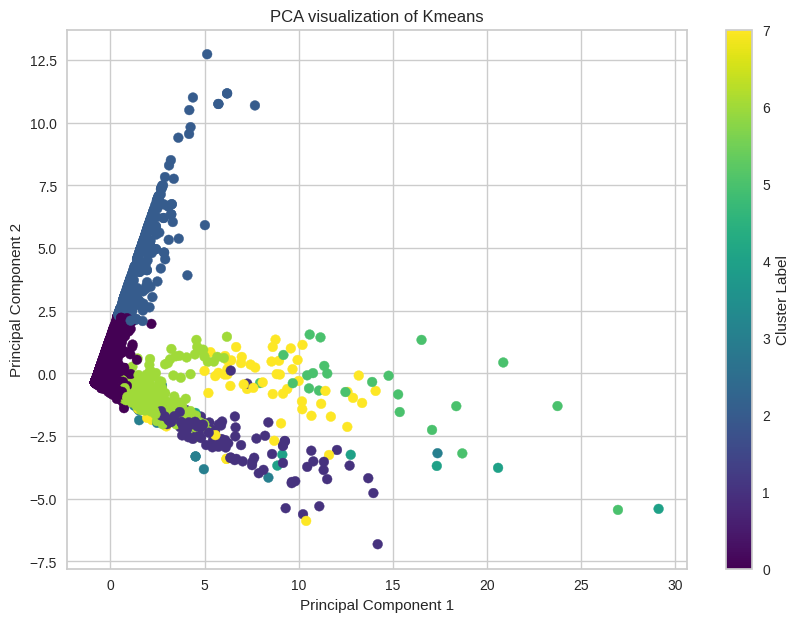

In [ ]:
visualizeResultsPCA('Kmeans',principal_components, y_kmeans)

### Agglomerative Clustering

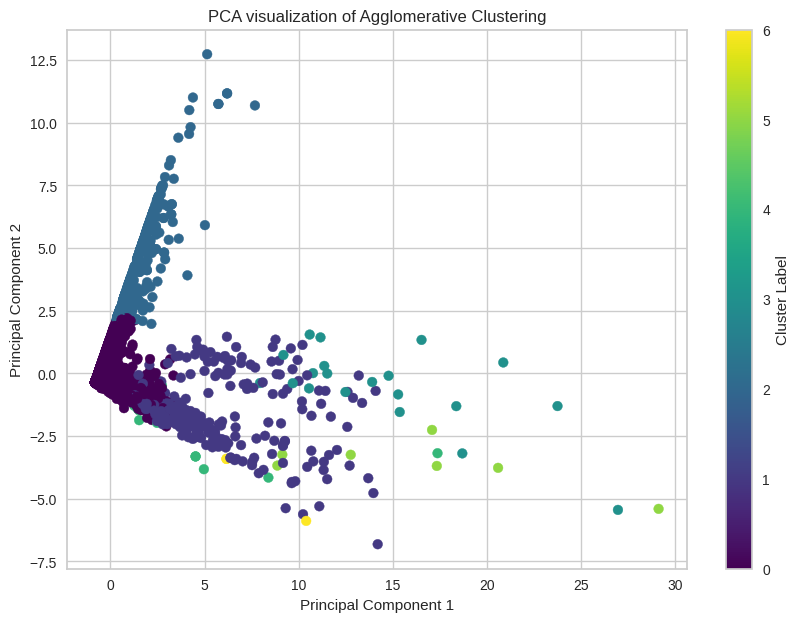

In [ ]:
visualizeResultsPCA('Agglomerative Clustering', principal_components, y_agg)

### DBScan

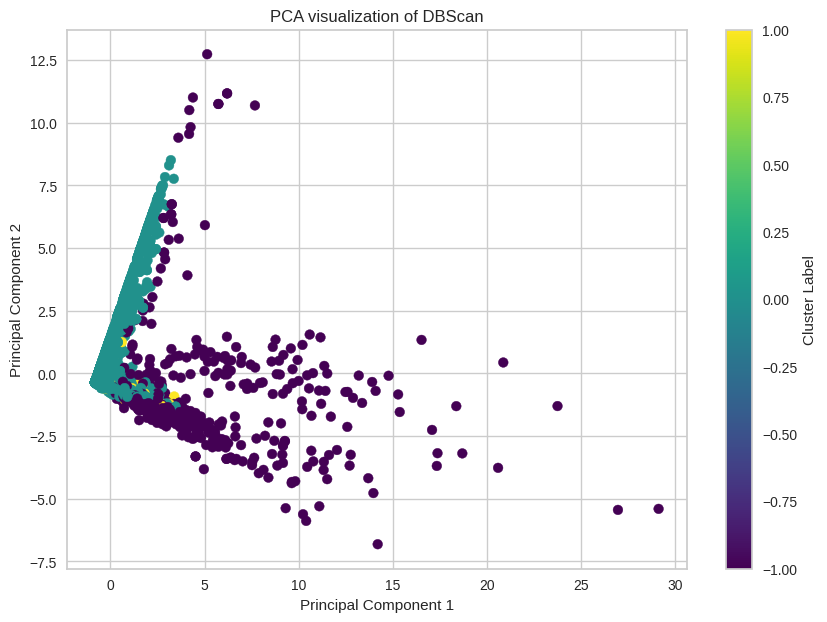

In [ ]:
visualizeResultsPCA('DBScan', principal_components, y_dbs)

## T-SNE

In [ ]:
# Inicializando o t-SNE
tsne = TSNE(n_components=2, random_state=42)

# Aplicando t-SNE aos dados
X_tsne = tsne.fit_transform(df_final)

### Kmeans

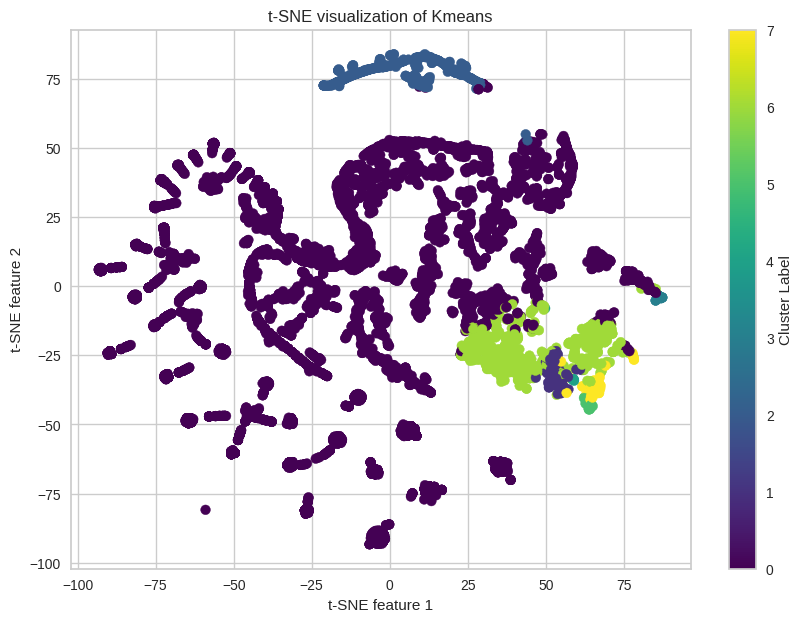

In [ ]:
visualizeResultsTSNE('Kmeans', X_tsne, y_kmeans)

### Agglomerative Clustering

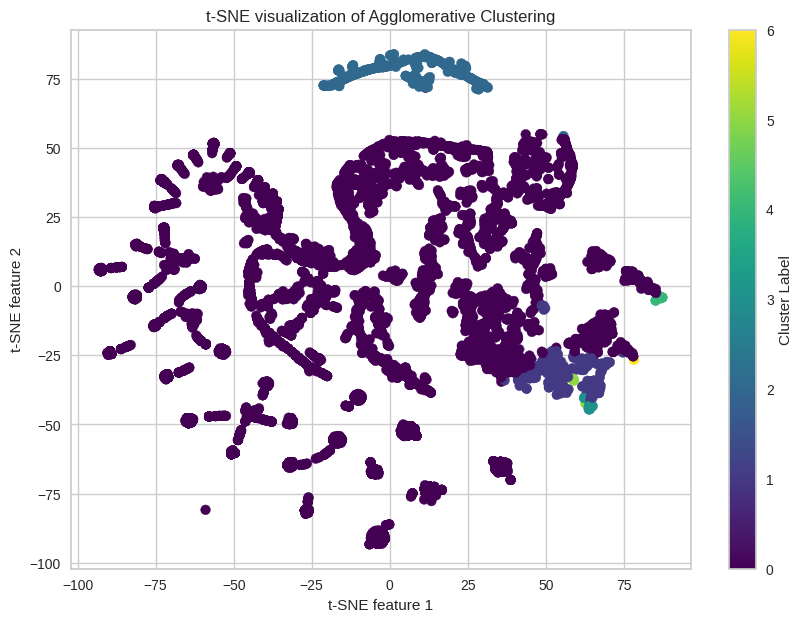

In [ ]:
visualizeResultsTSNE('Agglomerative Clustering', X_tsne, y_agg)

### DBScan

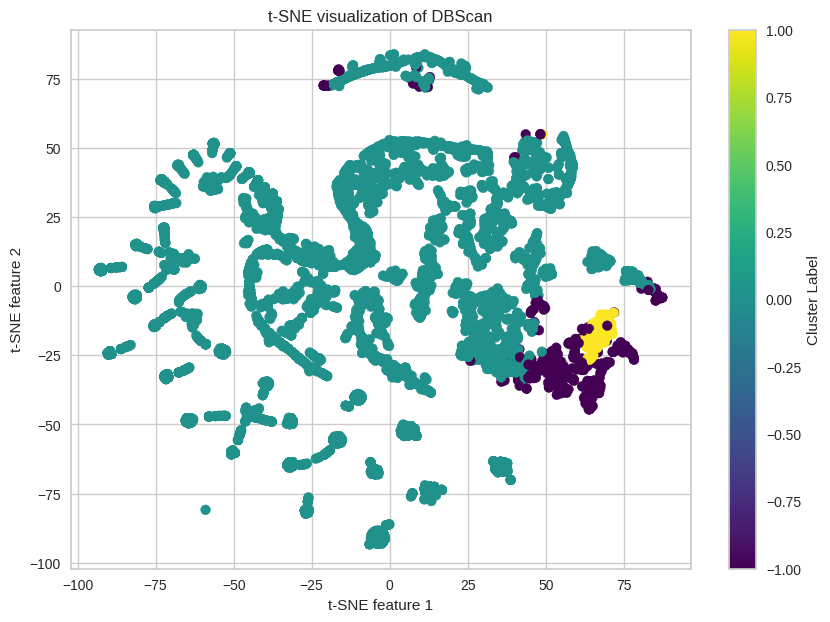

In [ ]:
visualizeResultsTSNE('DBScan', X_tsne, y_dbs)

# PCA 3D

In [70]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(df_final)
# Criar um DataFrame para os componentes principais
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2', 'PC3'])

In [75]:
def mostrar3D(labels):
  # Plotar o gráfico 3D
  fig = plt.figure(figsize=(10, 8))
  ax = fig.add_subplot(111, projection='3d')

  # Use cores para diferenciar os clusters, se você tiver essa informação
  scatter = ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], c=labels, cmap='tab20', s=20)

  # Adicionar títulos e labels
  ax.set_title('PCA 3D')
  ax.set_xlabel('PC1')
  ax.set_ylabel('PC2')
  ax.set_zlabel('PC3')

  # Adicionar uma barra de cores, se estiver usando clusters
  cbar = plt.colorbar(scatter)
  cbar.set_label('Cluster')

  plt.show()

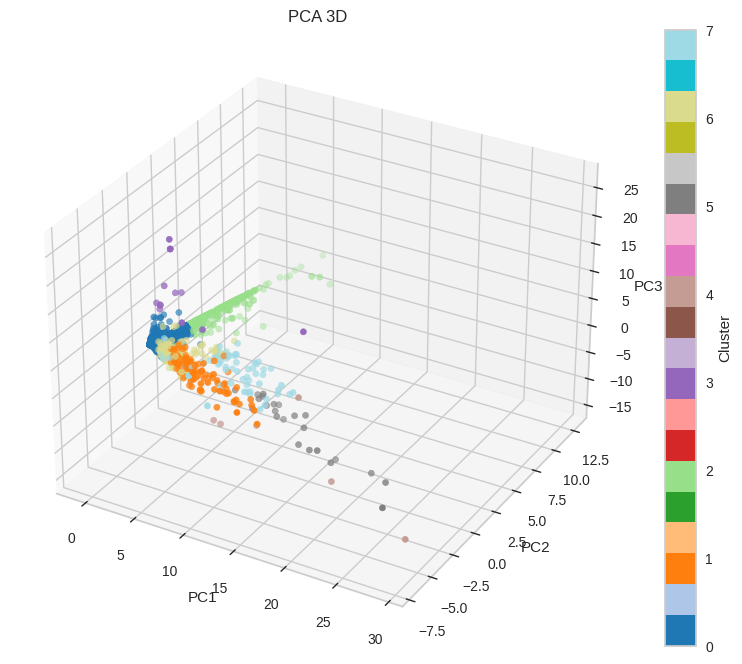

In [77]:
mostrar3D(y_kmeans)



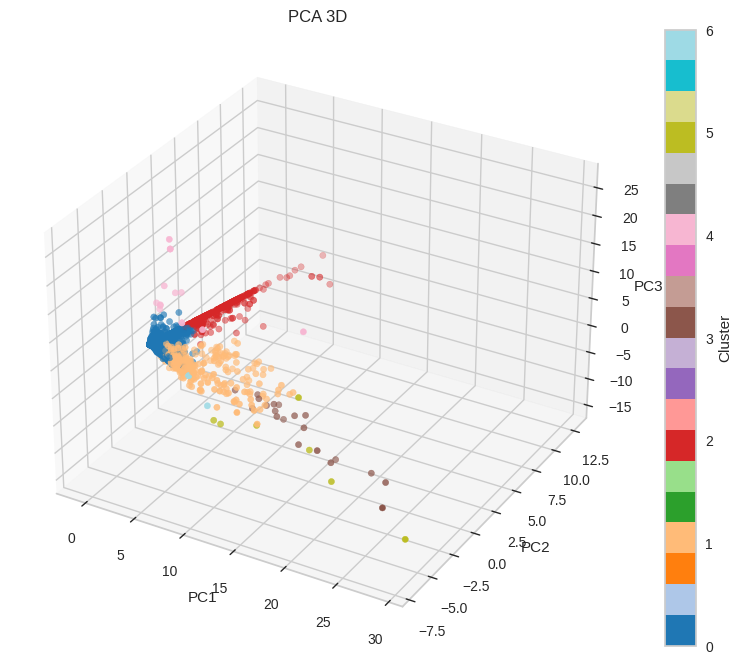

In [78]:
mostrar3D(y_agg)

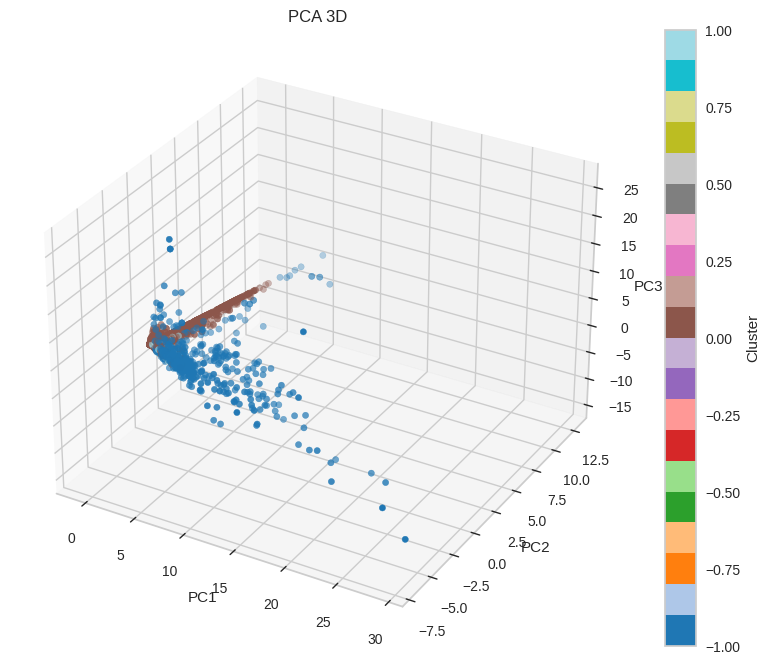

In [79]:
mostrar3D(y_dbs)

# Comparação das amostras entre os clusters

- Funções de comparação

In [81]:
def comparacaoDeAmostras(df):
  for cluster_label in df['cluster'].unique():
      # if cluster_label == -1:
      #     continue  # Ignorar o cluster de ruído
      print(f"Amostras no Cluster {cluster_label}:")
      cluster_samples = df[df['cluster'] == cluster_label]
      print(f"Número de amostras do cluster: {cluster_samples.shape[0]}")
      display(cluster_samples.head(7))
      print("\n")

In [64]:
def comparacaoDeMedias(df, n):
  dfs = []

  # Loop pelos clusters de 1 a 7 (ajuste conforme necessário)
  for i in range(0, n):
      # Calcula a média dos dados no cluster atual
      cluster_mean = df[df['cluster'] == i].mean()

      # Converte a série de médias em um DataFrame, adicionando o número do cluster
      cluster_mean_df = pd.DataFrame(cluster_mean).T
      cluster_mean_df['cluster'] = i  # Adiciona uma coluna com o número do cluster

      # Adiciona o DataFrame à lista
      dfs.append(cluster_mean_df)

  # Concatena todos os DataFrames da lista em um único DataFrame
  result_df = pd.concat(dfs, ignore_index=True)
  display(result_df)

## Kmeans

- Cluster 0: os mais diversos.
- Cluster 1: mais comentários.
- Cluster 2: mais likes.
- Cluster 3: mais sads.
- Cluster 4: mais hahas.
- Cluster 5: postagens mais engajadas.
- Cluster 6: medianos.
- Cluster 7: mais angrys.


In [65]:
comparacaoDeMedias(df_kmeans, 8)

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
0,101.758425,28.149931,4.562586,98.840956,2.219739,0.474381,0.123109,0.083735,0.014271,0
1,513.689320,5847.524272,515.601942,396.048544,101.708738,4.135922,8.368932,2.621359,0.805825,1
2,1821.005362,61.184987,11.613941,1815.243968,3.096515,2.428954,0.198391,0.032172,0.005362,2
3,456.714286,593.000000,62.571429,375.285714,44.285714,5.857143,2.000000,27.857143,1.428571,3
4,1250.428571,1038.285714,368.142857,891.428571,228.714286,28.571429,97.142857,3.000000,1.571429,4
5,1551.434783,1606.782609,830.652174,1105.347826,299.478261,131.826087,11.478261,1.521739,1.782609,5
6,265.000000,986.517665,220.345622,192.655914,67.043011,1.428571,2.824885,0.599078,0.439324,6
7,1190.619048,1557.523810,510.809524,967.936508,197.492063,11.984127,7.095238,1.793651,4.317460,7


In [ ]:
comparacaoDeAmostras(df_kmeans)

Amostras no Cluster 6:
Número de amostras do cluster: 651


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
0,529,512,262,432,92,3,1,1,0,6
6,503,614,72,418,70,10,2,0,3,6
45,372,456,37,334,31,1,1,1,4,6
49,309,444,36,254,42,2,8,3,0,6
53,240,255,111,193,44,1,1,0,1,6
67,362,468,86,305,56,0,0,1,0,6
72,248,247,34,208,33,3,2,0,2,6




Amostras no Cluster 0:
Número de amostras do cluster: 5816


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
1,150,0,0,150,0,0,0,0,0,0
2,227,236,57,204,21,1,1,0,0,0
3,111,0,0,111,0,0,0,0,0,0
4,213,0,0,204,9,0,0,0,0,0
5,217,6,0,211,5,1,0,0,0,0
7,295,453,53,260,32,1,1,0,1,0
8,203,1,0,198,5,0,0,0,0,0




Amostras no Cluster 7:
Número de amostras do cluster: 63


...

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
413,446,6148,120,352,80,7,5,0,2,1
475,358,5498,94,294,57,1,5,1,0,1
480,452,19013,161,353,92,2,3,2,0,1
482,543,4661,178,397,136,2,6,1,1,1
498,564,20990,154,473,82,3,3,3,0,1
2919,468,4143,719,378,84,0,3,3,0,1
2975,632,3416,836,493,126,6,4,2,1,1




Amostras no Cluster 4:
Número de amostras do cluster: 7


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
3868,509,17,131,386,3,18,102,0,0,4
3907,391,8,48,278,0,13,97,1,2,4
3913,414,5,61,356,0,1,57,0,0,4
4535,1758,1890,718,1181,385,89,100,2,1,4
4622,1874,2478,586,1380,394,6,76,17,1,4
4647,1168,1245,358,906,162,5,91,1,3,4
4660,2639,1625,675,1753,657,68,157,0,4,4




Amostras no Cluster 5:
Número de amostras do cluster: 23


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
4489,1360,1358,597,978,278,98,5,0,1,5
4491,1405,1156,607,1041,237,114,9,3,1,5
4494,874,1099,541,657,120,90,4,2,1,5
4502,1406,1609,726,1097,221,76,10,1,1,5
4517,1368,1794,718,980,306,74,3,4,1,5
4518,1741,2257,2139,1155,504,69,11,2,0,5
4526,1678,1499,685,1227,165,278,8,0,0,5


## Agglomerative Clustering

- Cluster 0: os mais diversos.
- Cluster 1: mais comentários.
- Cluster 2: mais likes.
- Cluster 3: mais engajados.
- Cluster 4: mais sads.
- Cluster 5: mais reações.
- Cluster 6: mais angrys.


In [66]:
comparacaoDeMedias(df_agg,7)

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
0,108.910287,89.234110,19.355048,101.058646,6.864638,0.537486,0.275321,0.119195,0.051989,0
1,622.023026,3113.131579,442.789474,485.967105,120.825658,5.246711,7.220395,1.680921,1.082237,1
2,1775.463104,58.829517,11.137405,1770.038168,2.834606,2.371501,0.183206,0.030534,0.005089,2
3,1564.900000,1561.950000,831.000000,1110.350000,302.250000,138.900000,10.050000,1.400000,1.950000,3
4,456.714286,593.000000,62.571429,375.285714,44.285714,5.857143,2.000000,27.857143,1.428571,4
5,1421.428571,1368.142857,508.142857,1003.285714,273.857143,43.285714,96.142857,3.285714,1.571429,5
6,239.000000,34.000000,3.333333,210.666667,0.333333,3.000000,1.333333,0.666667,23.000000,6


In [82]:
comparacaoDeAmostras(df_agg)


Amostras no Cluster 0:
Número de amostras do cluster: 6309


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
0,529,512,262,432,92,3,1,1,0,0
1,150,0,0,150,0,0,0,0,0,0
2,227,236,57,204,21,1,1,0,0,0
3,111,0,0,111,0,0,0,0,0,0
4,213,0,0,204,9,0,0,0,0,0
5,217,6,0,211,5,1,0,0,0,0
7,295,453,53,260,32,1,1,0,1,0




Amostras no Cluster 1:
Número de amostras do cluster: 304


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
6,503,614,72,418,70,10,2,0,3,1
99,1493,1979,753,1333,139,9,3,8,1,1
198,571,888,107,459,107,1,1,1,2,1
343,1379,769,69,1131,234,4,4,2,4,1
413,446,6148,120,352,80,7,5,0,2,1
475,358,5498,94,294,57,1,5,1,0,1
480,452,19013,161,353,92,2,3,2,0,1




Amostras no Cluster 4:
Número de amostras do cluster: 14


...

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
3313,215,44,0,176,1,3,4,0,31,6
6204,251,29,5,228,0,3,0,1,19,6
6255,251,29,5,228,0,3,0,1,19,6




Amostras no Cluster 5:
Número de amostras do cluster: 7


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
3868,509,17,131,386,3,18,102,0,0,5
3907,391,8,48,278,0,13,97,1,2,5
4535,1758,1890,718,1181,385,89,100,2,1,5
4542,1611,2314,1041,1139,316,104,50,2,0,5
4622,1874,2478,586,1380,394,6,76,17,1,5
4647,1168,1245,358,906,162,5,91,1,3,5
4660,2639,1625,675,1753,657,68,157,0,4,5




Amostras no Cluster 3:
Número de amostras do cluster: 20


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
4489,1360,1358,597,978,278,98,5,0,1,3
4491,1405,1156,607,1041,237,114,9,3,1,3
4494,874,1099,541,657,120,90,4,2,1,3
4518,1741,2257,2139,1155,504,69,11,2,0,3
4526,1678,1499,685,1227,165,278,8,0,0,3
4527,1290,1530,627,1032,149,106,3,0,0,3
4528,1309,1267,413,1006,100,200,3,0,0,3


## DBScan
- Cluster -1: Mais engajados.
- Cluster 0: mais diversidade.
- Cluster 1: média de valores.

In [69]:
comparacaoDeMedias(df_dbs, 2)

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
0,193.113137,67.074334,15.394889,187.080879,5.252766,0.511921,0.193237,0.072308,0.0,0
1,218.291139,612.575949,147.424051,160.810127,53.329114,1.094937,1.702532,0.354430,1.0,1


In [84]:
display(pd.DataFrame(df_dbs[df_dbs['cluster'] == -1].mean()).T)

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
0,733.955789,2220.014737,337.004211,610.837895,100.218947,11.856842,7.16,2.522105,1.347368,-1.0


In [ ]:
comparacaoDeAmostras(df_dbs)

Amostras no Cluster 0:
Número de amostras do cluster: 6417


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
0,529,512,262,432,92,3,1,1,0,0
1,150,0,0,150,0,0,0,0,0,0
2,227,236,57,204,21,1,1,0,0,0
3,111,0,0,111,0,0,0,0,0,0
4,213,0,0,204,9,0,0,0,0,0
5,217,6,0,211,5,1,0,0,0,0
8,203,1,0,198,5,0,0,0,0,0




Amostras no Cluster -1:
Número de amostras do cluster: 475


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
6,503,614,72,418,70,10,2,0,3,-1
45,372,456,37,334,31,1,1,1,4,-1
49,309,444,36,254,42,2,8,3,0,-1
72,248,247,34,208,33,3,2,0,2,-1
99,1493,1979,753,1333,139,9,3,8,1,-1
107,190,0,31,171,0,0,0,19,0,-1
128,688,0,0,632,34,0,0,22,0,-1




Amostras no Cluster 1:
Número de amostras do cluster: 158


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
7,295,453,53,260,32,1,1,0,1,1
42,236,181,21,201,33,0,1,0,1,1
47,128,60,11,114,13,0,0,0,1,1
48,186,235,46,163,19,0,3,0,1,1
53,240,255,111,193,44,1,1,0,1,1
69,216,251,34,199,16,0,0,0,1,1
73,132,89,40,110,20,1,0,0,1,1
